In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
import pytz
from tqdm import tqdm
from datetime import timedelta
from dateutil.relativedelta import relativedelta

In [2]:
sales = pd.read_csv('pedidos-1743765883268.csv', sep=';', encoding='latin1')

In [3]:
df = sales[['account_id', 'sales_channel_id']].value_counts()
df = pd.DataFrame(df).reset_index()

In [4]:
# EPOCHS = 1000
# BATCH_SIZE = 32
# VALID_SPLIT = 0.1

In [5]:
SAO_PAULO_TZ = pytz.timezone('America/Sao_Paulo')
LOOKBACK = 1
# SEASONAL_PERIODS = (24, 24*7)
# COVERAGE = 0.33
END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
# START_DATE = END_DATE - timedelta(hours=END_DATE.hour)
START_DATE = END_DATE - timedelta(hours=23)
# TEST_SIZE = int((END_DATE - START_DATE).seconds / 60**2 + 1)

In [6]:
# OOT_DATE = START_DATE + timedelta(hours=23)

In [7]:
# OOT_PERIODS = int((OOT_DATE - END_DATE).seconds / 60**2 + 1)

In [8]:
# oot_dates = pd.DatetimeIndex([END_DATE+timedelta(hours=h) for h in range(1, OOT_PERIODS)], freq='h')
# df_oot = pd.DataFrame(index=oot_dates)

In [9]:
df.drop('count', axis=1, inplace=True)
for account_id in df['account_id'].unique():
    df = pd.concat([df, pd.DataFrame({'account_id': [account_id], 'sales_channel_id': ['ALL']})], ignore_index=True)

In [10]:
# df

In [11]:
# id_pairs = list(zip(df['account_id'], df['sales_channel_id']))
# id_pairs = list(zip(df_filtered['account_id'], df_filtered['sales_channel_id']))

In [12]:
# weights_chan = {}
# for account_id, sales_channel_id in tqdm(id_pairs):
       
#     if sales_channel_id == 'ALL':
#         cond = (sales['account_id'] == account_id) & \
#                (sales['status'].notna())
#     else:
#         cond = (sales['account_id'] == account_id) & \
#                (sales['sales_channel_id'] == sales_channel_id) & \
#                (sales['status'].notna())

#     df_client = sales[cond].drop(['account_id', 'sales_channel_id'], axis=1)
#     df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
#     df_client = df_client.sort_values('created_date').reset_index(drop=True)
#     df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)

#     df_client_mod = df_client.groupby('created_date').agg(price_total_agg=('price_total', 'sum'), n_orders=('created_date', 'count'))
#     df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')

#     end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
#     start_date = end_date - relativedelta(months=LOOKBACK)
#     date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
#     df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')
    
#     weights_chan[account_id] = {} if account_id not in weights_chan else weights_chan[account_id]
    
#     df = df_client_mod['n_orders'].fillna(0)
#     df = df.loc[df.index < START_DATE].copy()
    
#     weights_chan[account_id][sales_channel_id] = df.median()

In [13]:
# weights_df = pd.DataFrame(weights_chan)

# weights_df

In [14]:
# weights_df = weights_df.stack().reset_index().rename(columns={'level_0': 'sales_channel_id', 'level_1': 'account_id', 0: 'weights'}).sort_values(by=['account_id', 'sales_channel_id'])

# weights_df

In [15]:
# weights_chan_df = weights_df.groupby('account_id')['weights'].apply(lambda x: x / x.sum()).fillna(0).reset_index().rename(columns={0: 'weights'}).drop('level_1', axis=1)

# weights_chan_df = pd.concat([weights_df['sales_channel_id'].reset_index(drop=True), weights_chan_df], axis=1)

# weights_chan_df.sort_values(by=['account_id', 'weights'], ascending=False, inplace=True)
# weights_chan_df.reset_index(drop=True, inplace=True)

# weights_chan_df

In [16]:
# joblib.dump(weights_chan_df, 'weights_chan.pkl')
weights_chan_df = joblib.load('weights_chan.pkl')

In [17]:
# weights_acc_df = weights_df.groupby('account_id')['weights'].sum() / weights_df.groupby('account_id')['weights'].sum().sum()

# weights_acc_df

In [18]:
# weights_acc_df.sort_values(ascending=False, inplace=True)

# weights_acc_df

In [19]:
# joblib.dump(weights_acc_df, 'weights_acc.pkl')
weights_acc_df = joblib.load('weights_acc.pkl')

In [20]:
dbname = 'railway'
username = 'sinatra'
pwd = '781B3XjpeuqE'
hostname = 'monorail.proxy.rlwy.net'
port = 25096

connection = psycopg2.connect(database=dbname, user=username, password=pwd, host=hostname, port=port)
cursor = connection.cursor()

In [21]:
cursor.execute("select distinct account_id, channel from public.forecast where model='TBATS';")
res_tbats = cursor.fetchall()

cursor.execute("select distinct account_id, channel from public.forecast where model='GradientBoosting';")
res_gb = cursor.fetchall()

cursor.execute("select distinct account_id, channel from public.forecast where model='LSTM';")
res_lstm = cursor.fetchall()

cursor.execute("select distinct account_id, channel from public.forecast where model='Ensemble';")
res_ens = cursor.fetchall()

cursor.execute("select distinct account_id, channel from public.forecast where model='amazon/chronos-bolt-base:v2025-03-09:cl(370):q(0.3,0.7)';")
res_chronos1 = cursor.fetchall()

cursor.execute("select distinct account_id, channel from public.forecast where model='Chronos';")
res_chronos2 = cursor.fetchall()

cursor.execute("select distinct account_id, channel from public.forecast where model='MEDIAN_MAD_60';")
res_median = cursor.fetchall()

In [ ]:
id_pairs = (
    set(res_tbats)
    .intersection(set(res_gb))
    .intersection(set(res_lstm))
    .intersection(set(res_ens))
    .intersection(set(res_chronos1))
    .intersection(set(res_chronos2))
    .intersection(set(res_median))
)

# id_pairs = set(res_tbats).intersection(set(res_gb))

In [23]:
id_pairs

{('05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6', '1'),
 ('05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6', '3'),
 ('05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6', '5'),
 ('05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6', '6'),
 ('05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6', 'ALL'),
 ('0661e926-f219-456e-bde5-612fee6f891c', '1'),
 ('0661e926-f219-456e-bde5-612fee6f891c', 'ALL'),
 ('0ad2f65b-ee0e-4d50-93e2-84b76282325f', '1'),
 ('0ad2f65b-ee0e-4d50-93e2-84b76282325f', '2'),
 ('173e2b27-8bc6-44d1-b581-a1913d6b1894', '1'),
 ('173e2b27-8bc6-44d1-b581-a1913d6b1894', '11'),
 ('173e2b27-8bc6-44d1-b581-a1913d6b1894', '14'),
 ('173e2b27-8bc6-44d1-b581-a1913d6b1894', '16'),
 ('173e2b27-8bc6-44d1-b581-a1913d6b1894', '18'),
 ('173e2b27-8bc6-44d1-b581-a1913d6b1894', '5'),
 ('173e2b27-8bc6-44d1-b581-a1913d6b1894', '8'),
 ('173e2b27-8bc6-44d1-b581-a1913d6b1894', '9'),
 ('173e2b27-8bc6-44d1-b581-a1913d6b1894', 'ALL'),
 ('2058f680-aace-4b31-aed4-f34397b75096', '1'),
 ('22fde42e-45d7-46cd-9d6f-3a4dbabbc579', '1'),
 ('22fde42e-45d7-46cd-9d6f-3a4

In [24]:
# gb_models = [f'GradientBoosting_{int(10*n)}' for n in range(1, 10)]
# lstm_models = [f'LSTM_{int(10*n)}' for n in range(1, 10)]
# tbats_models = [f'TBATS_{int(10*n)}' for n in range(1, 10)]
# ens_models = [f'Ensemble_{int(10*n)}' for n in range(1, 10)]
# chronos_models = [f'Chronos_{int(10*n)}' for n in range(1, 10)]

In [25]:
# id_pairs

In [26]:
models = ['GradientBoosting', 'LSTM', 'TBATS', 'Ensemble', 'Chronos']




GradientBoosting


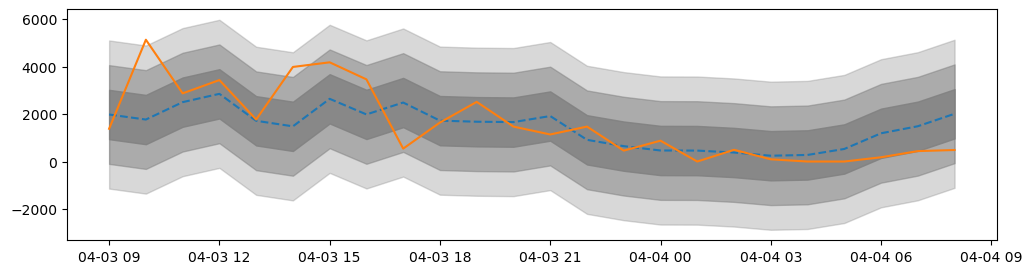

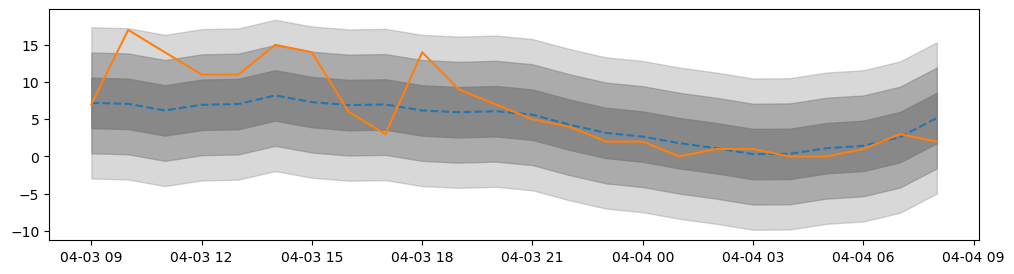

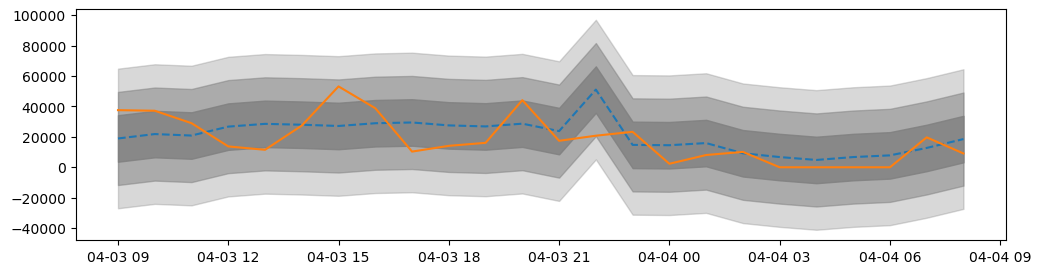

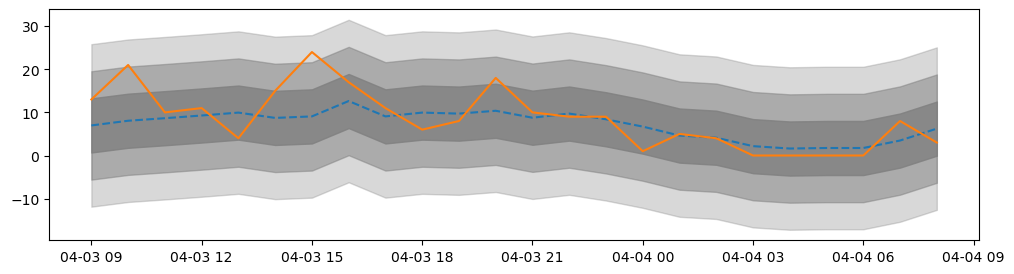

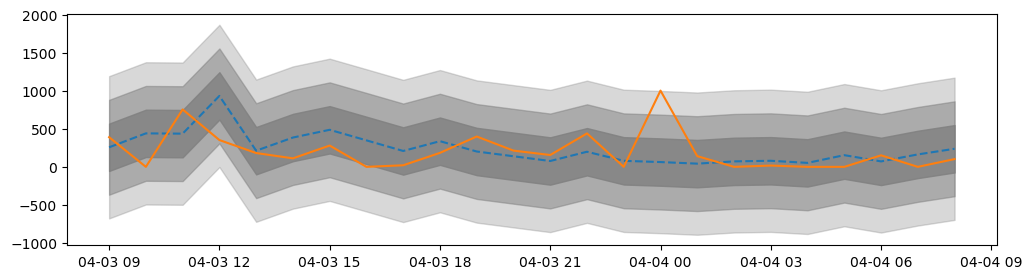

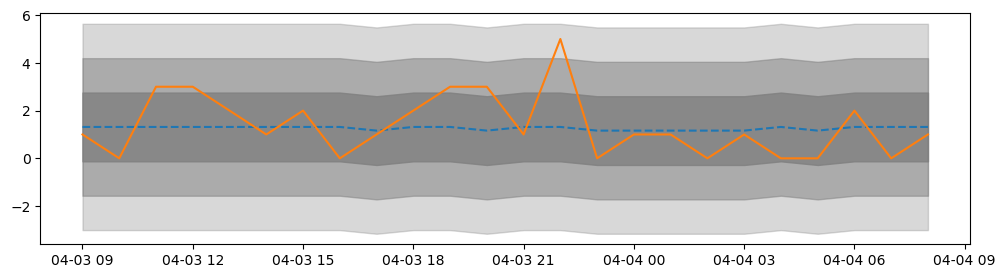

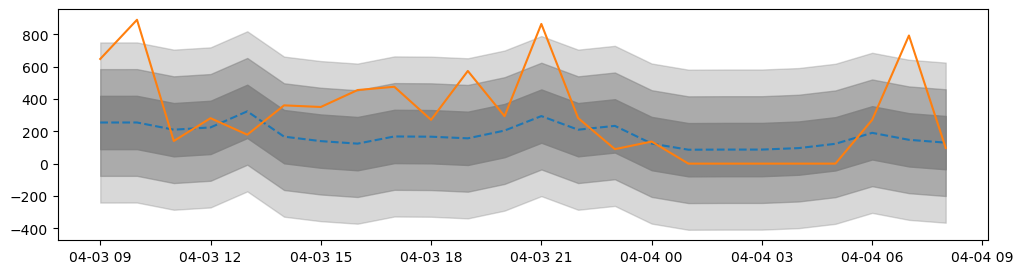

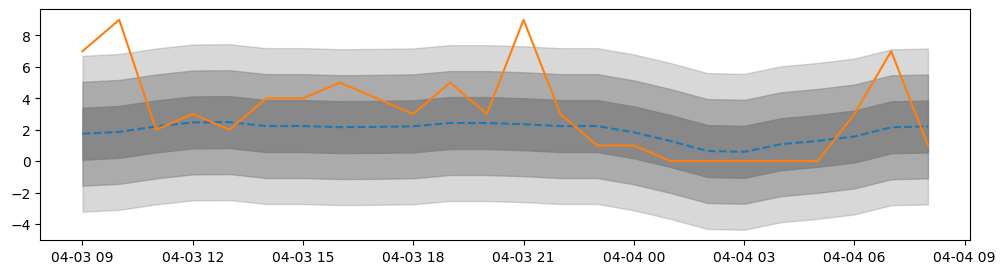

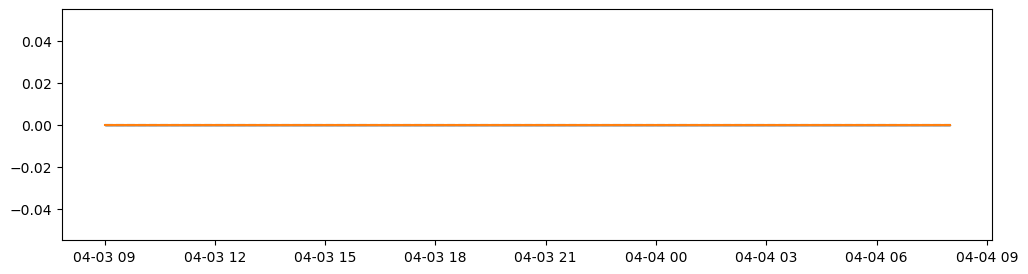

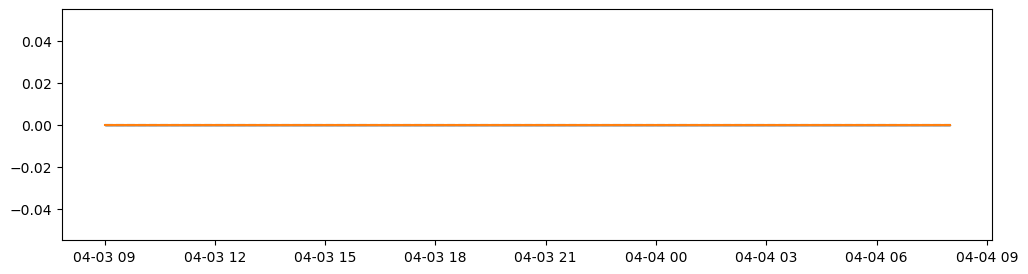

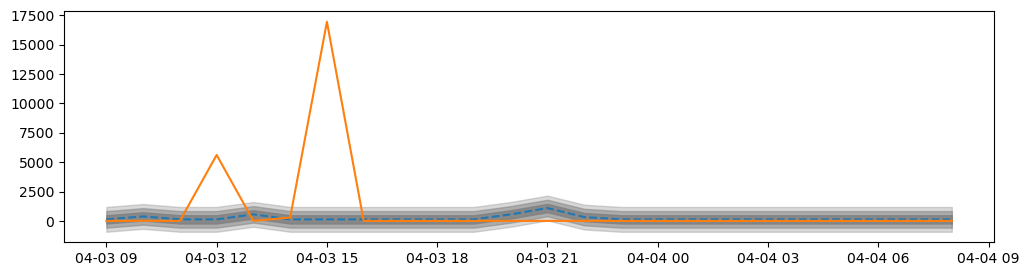

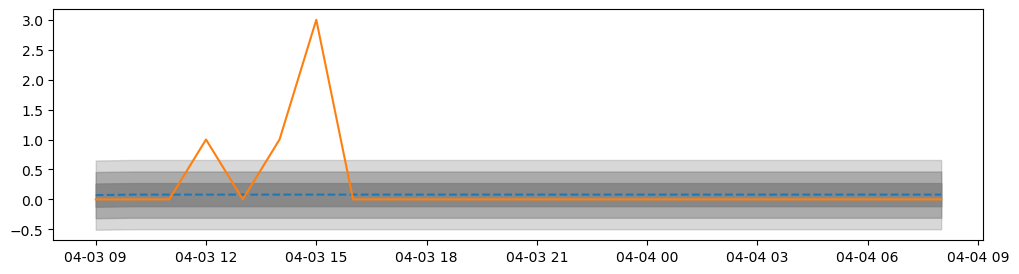

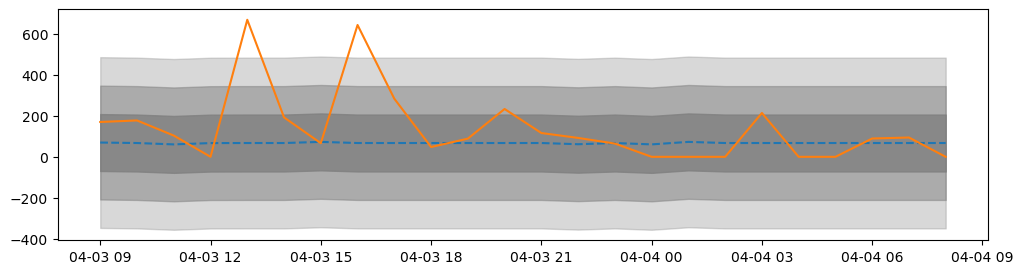

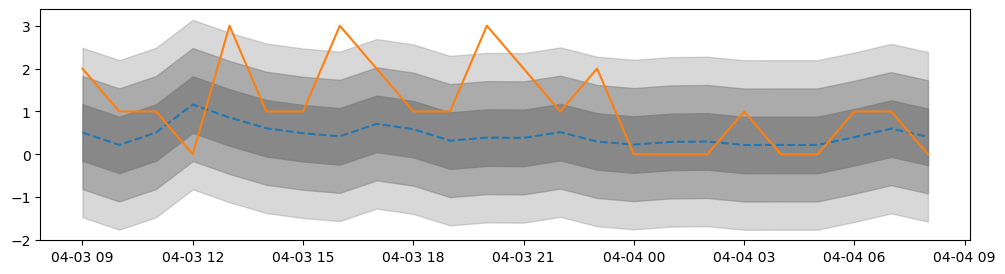

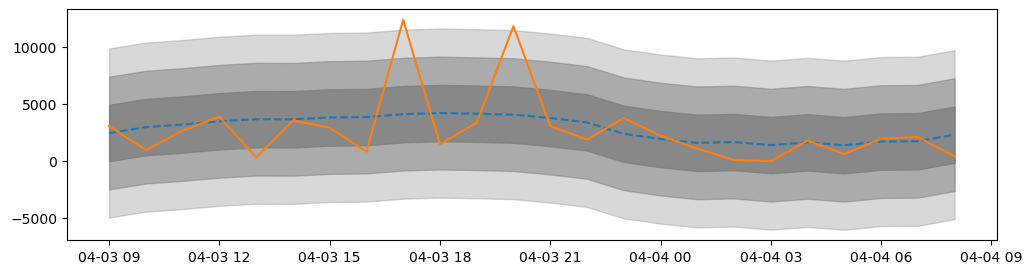

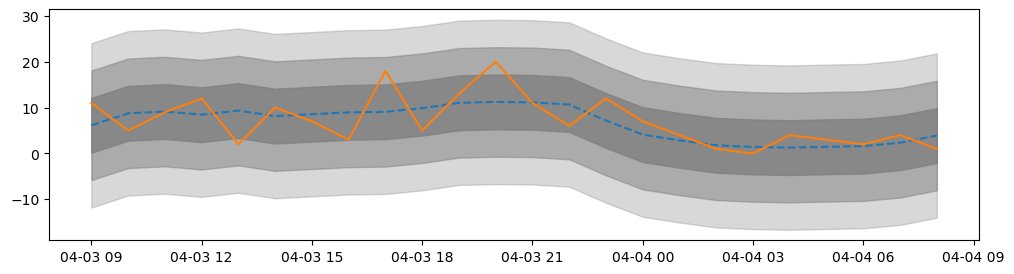

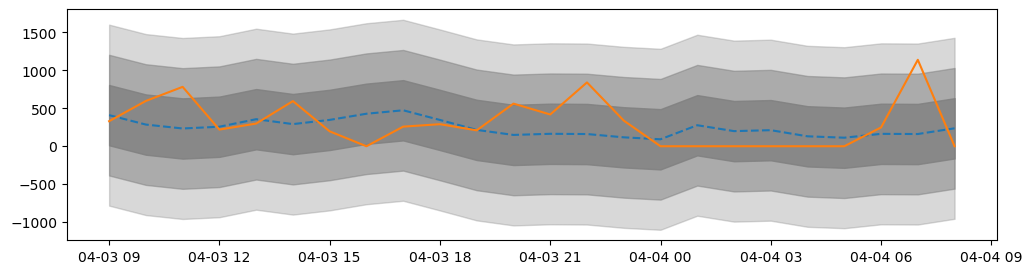

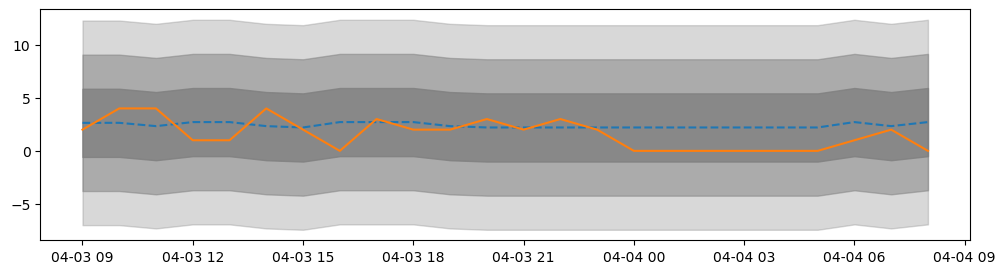

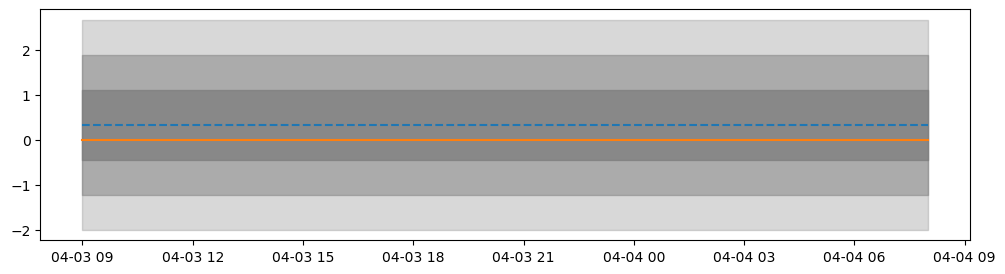

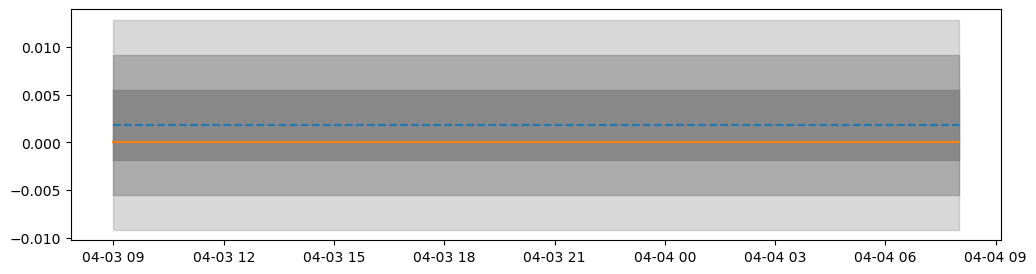

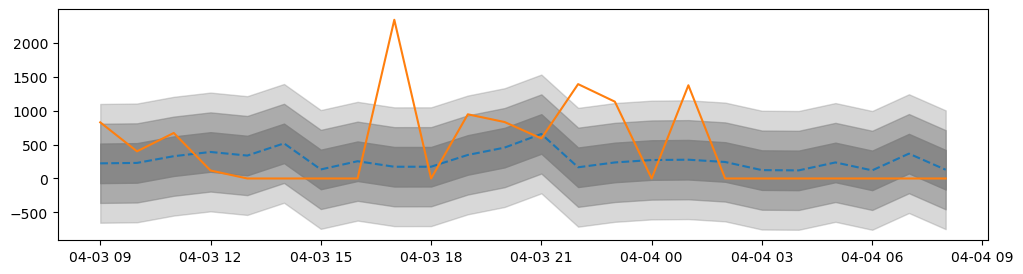

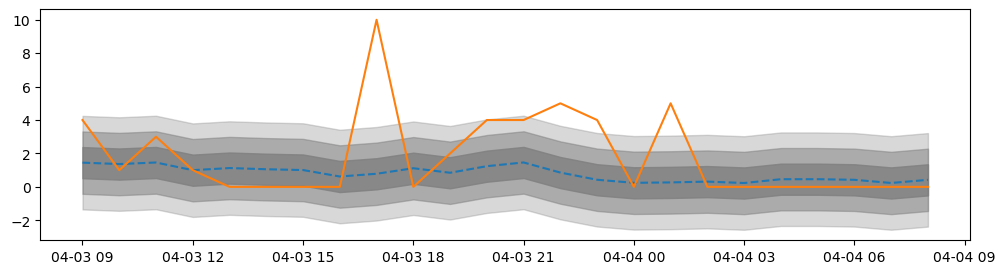

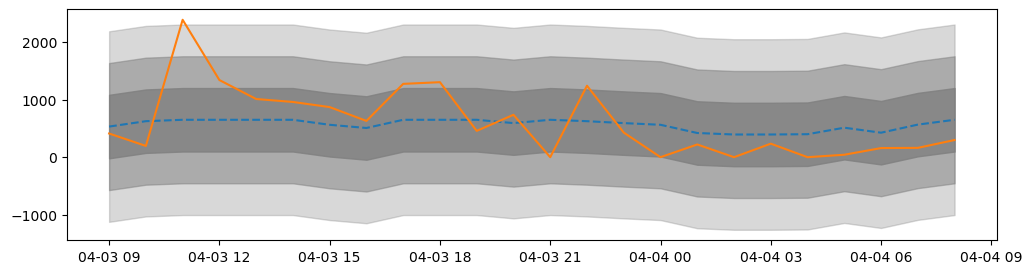

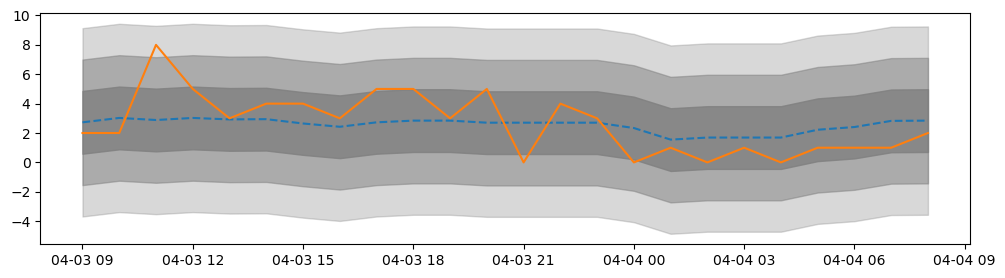

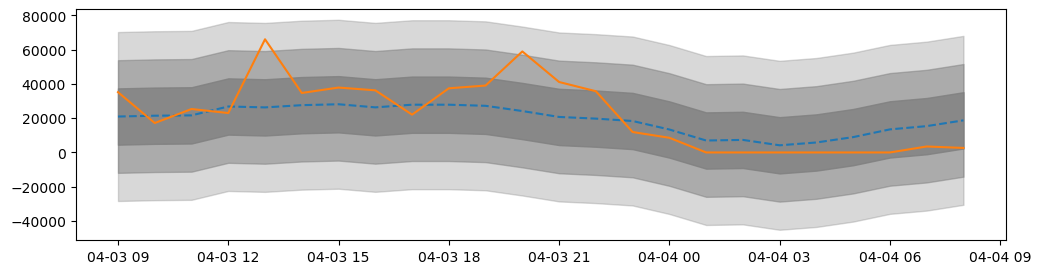

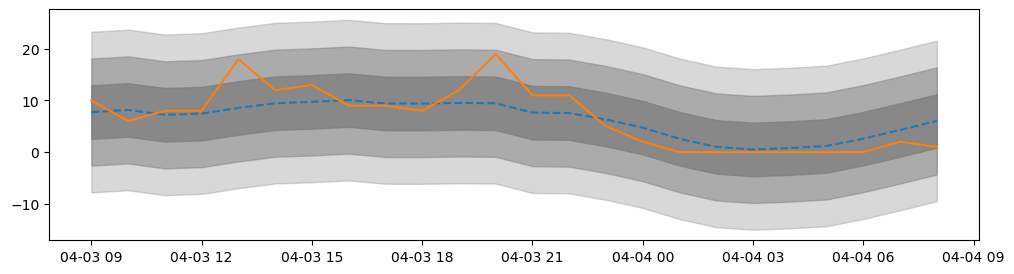

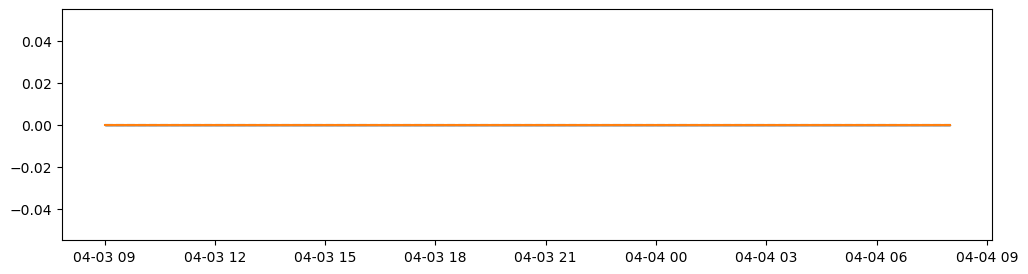

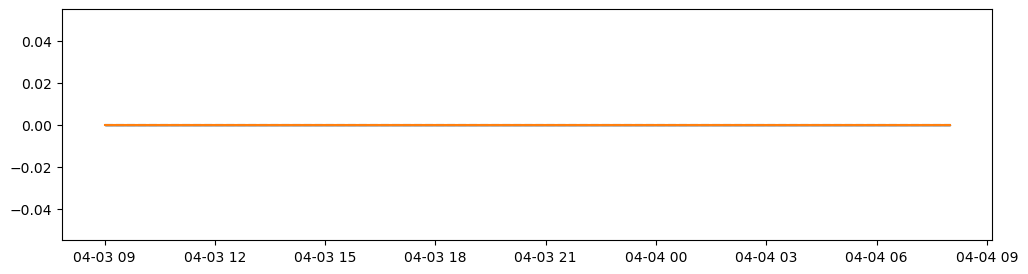

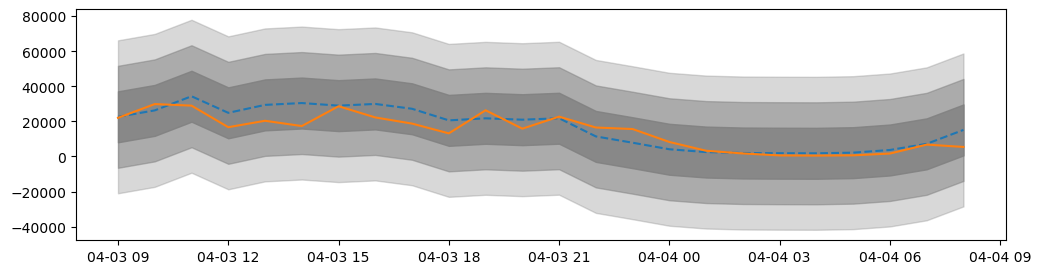

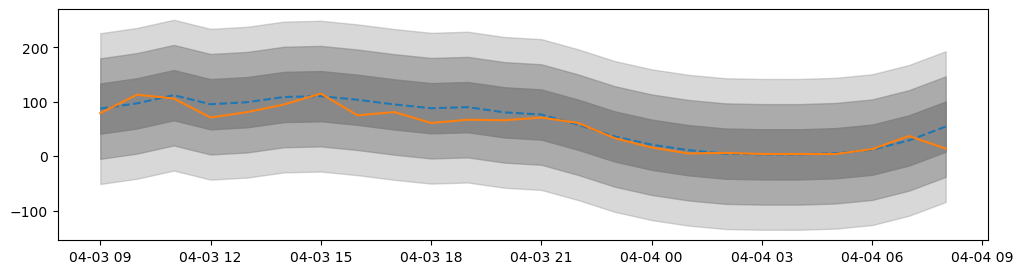

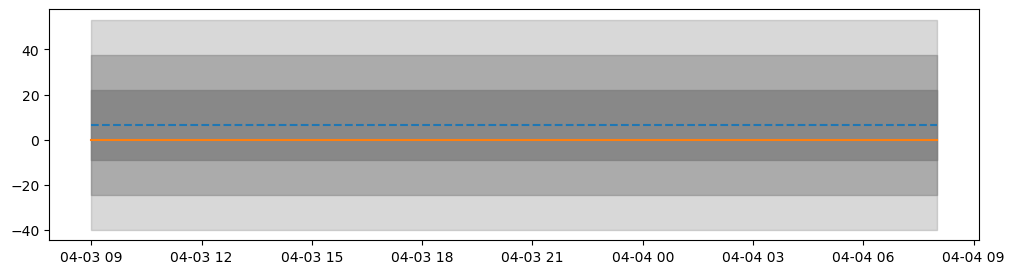

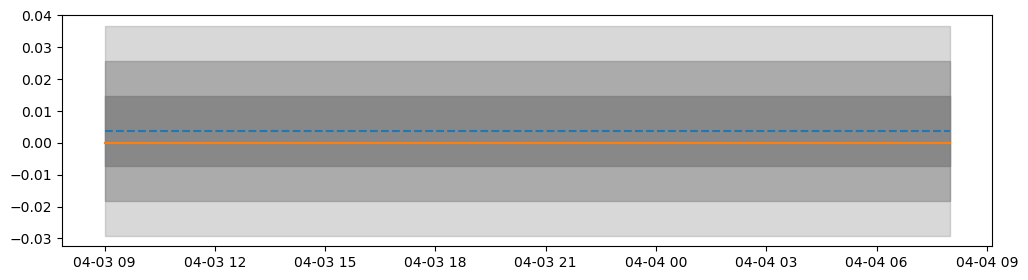

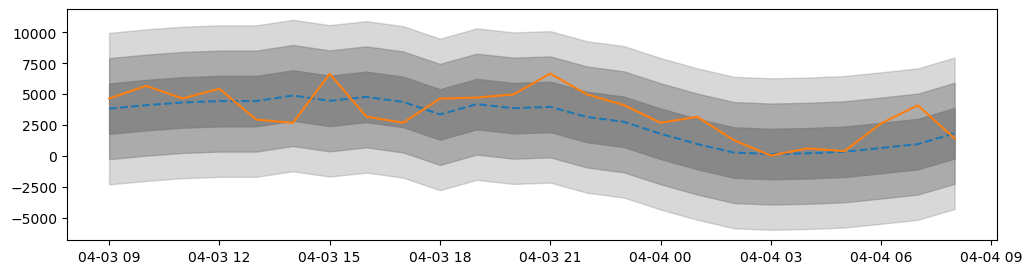

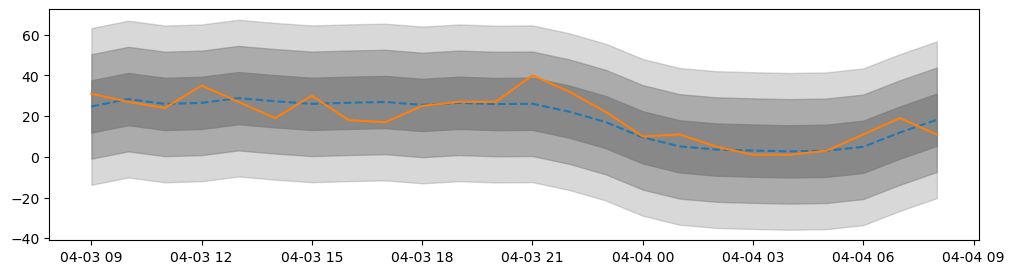

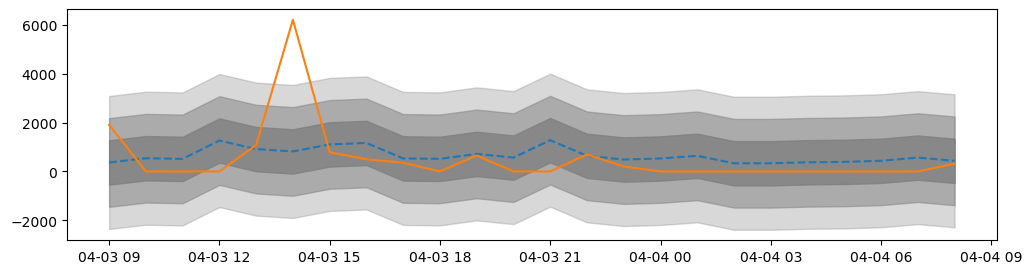

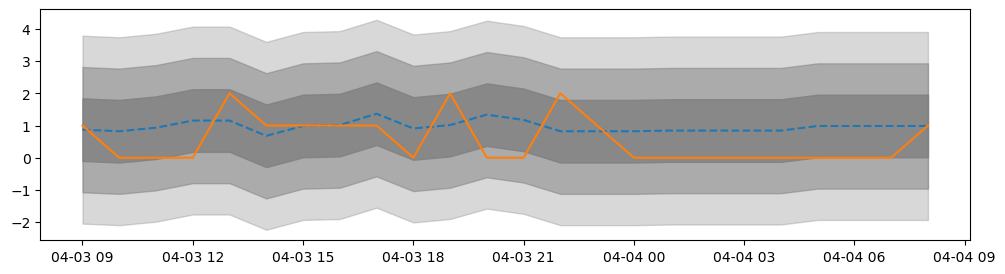

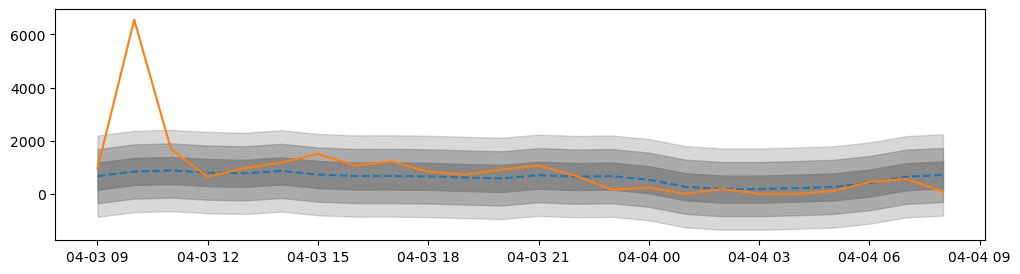

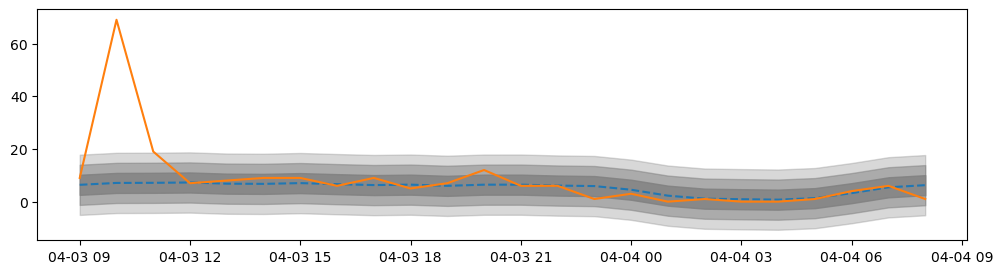

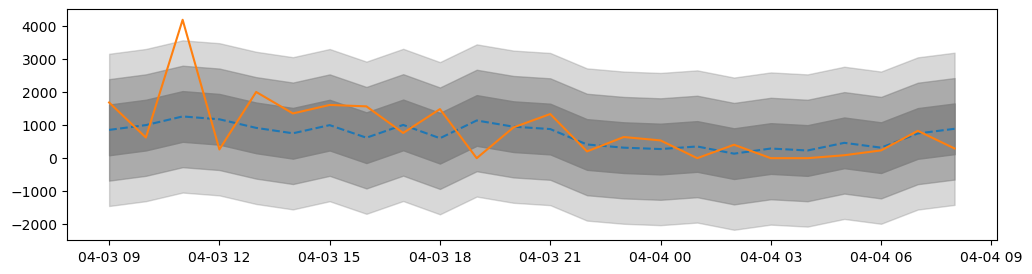

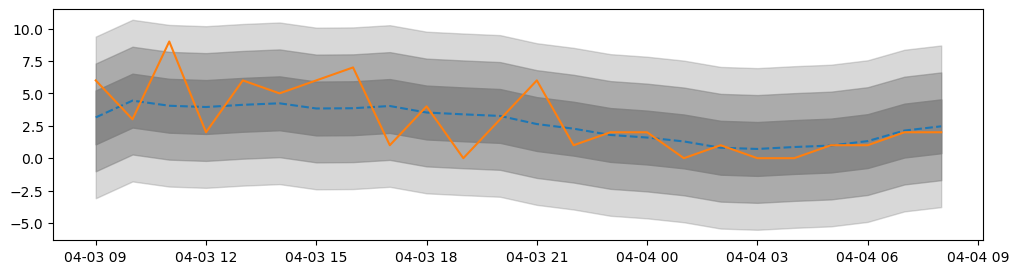

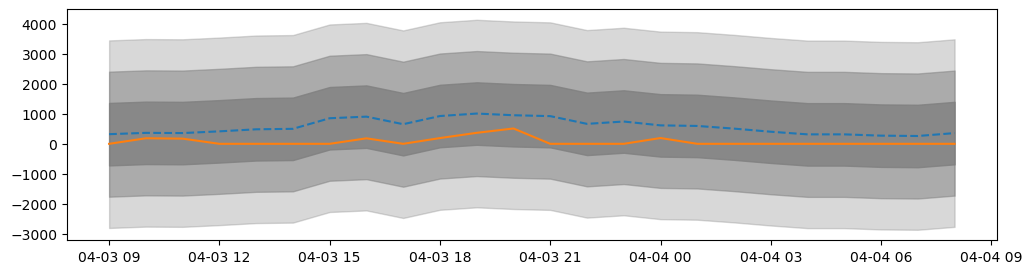

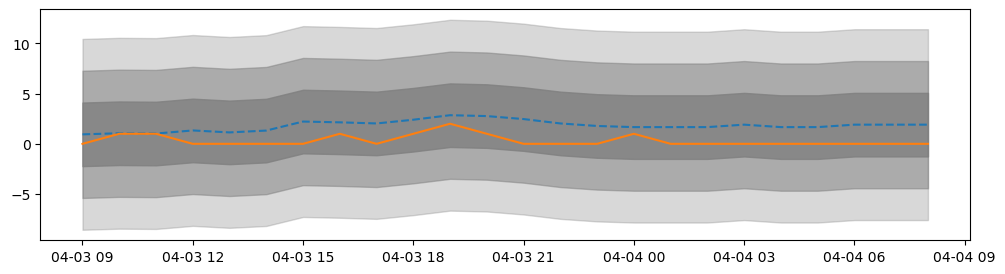

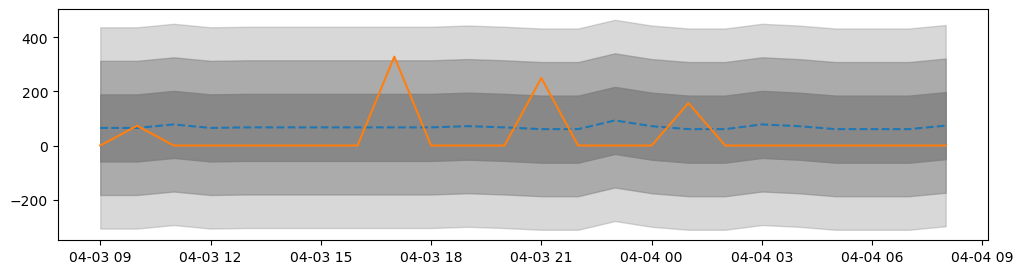

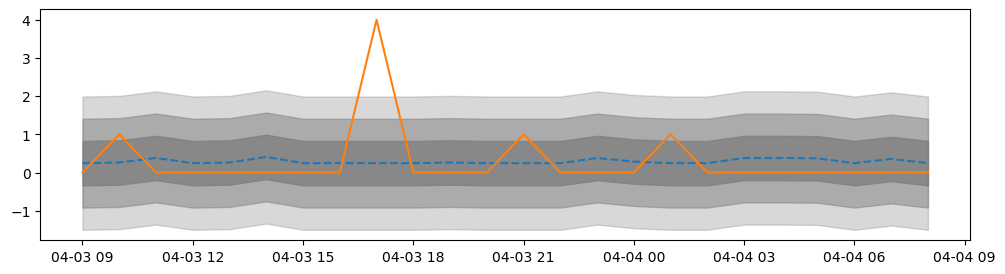

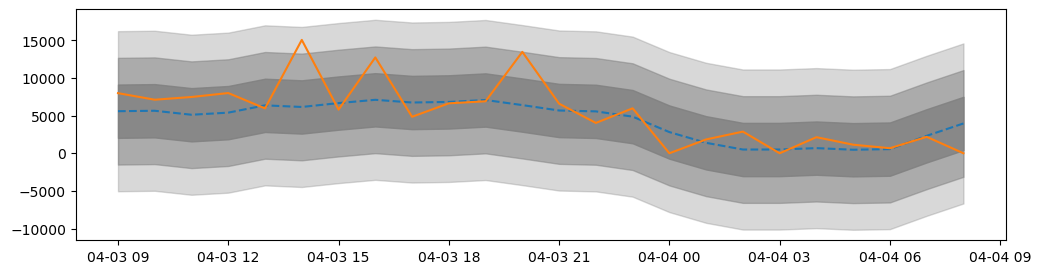

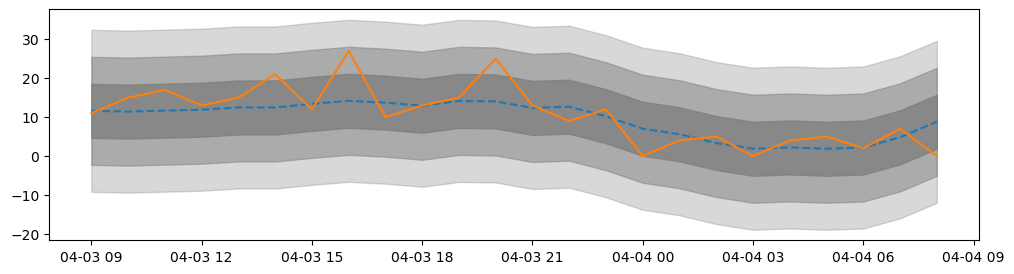

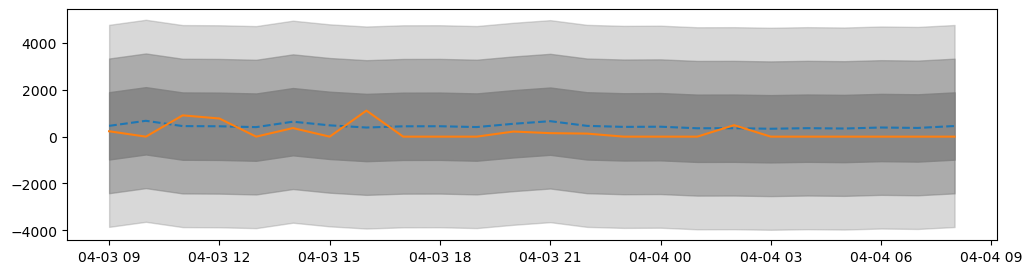

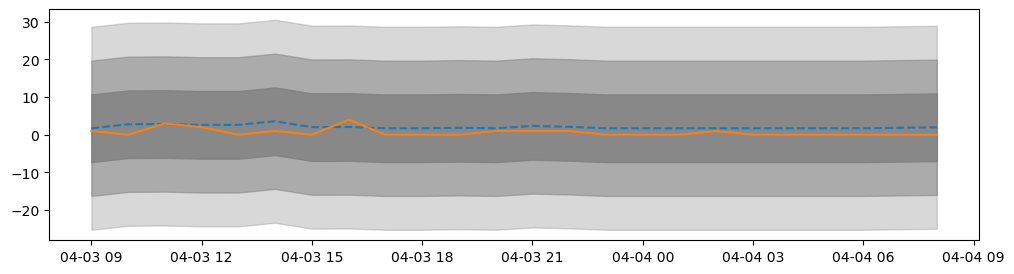

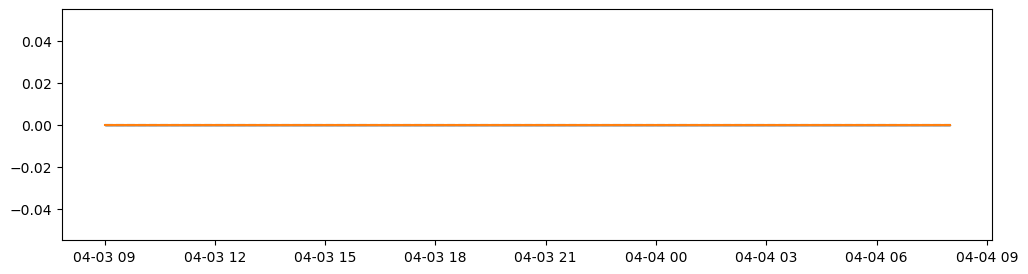

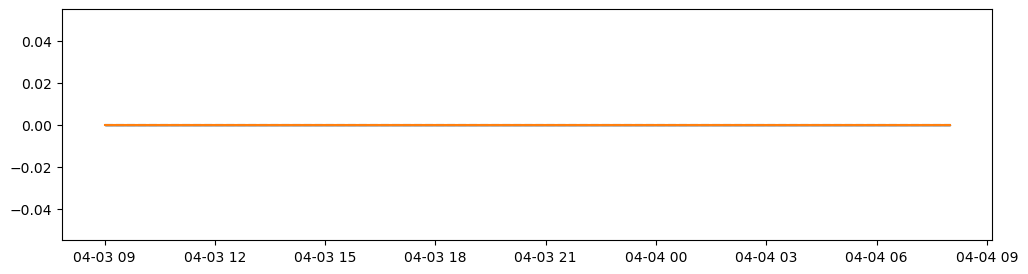

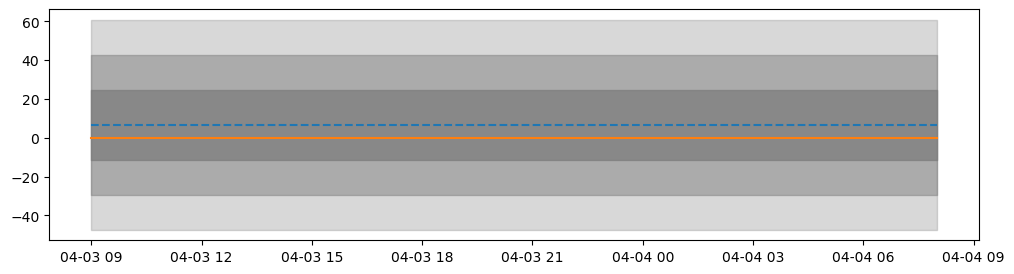

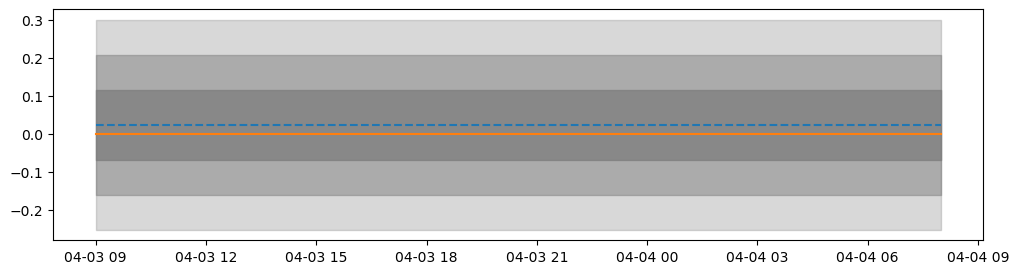

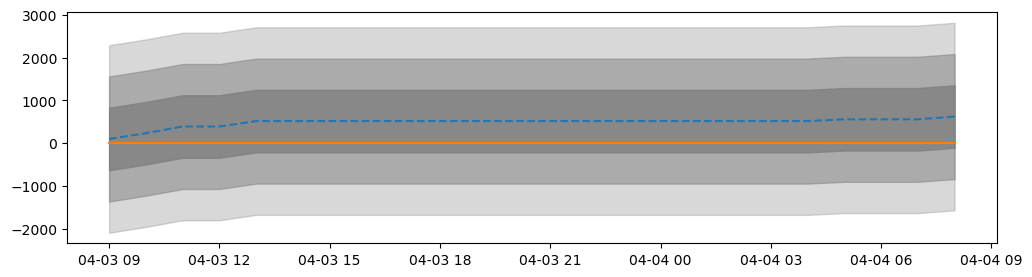

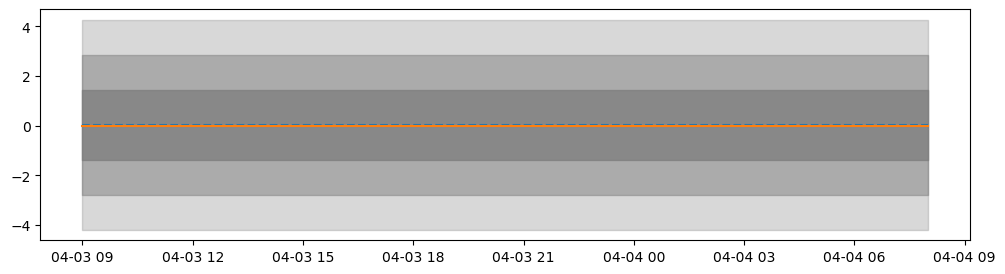

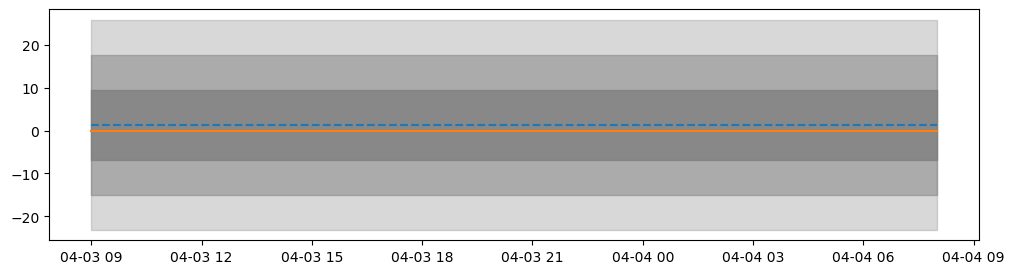

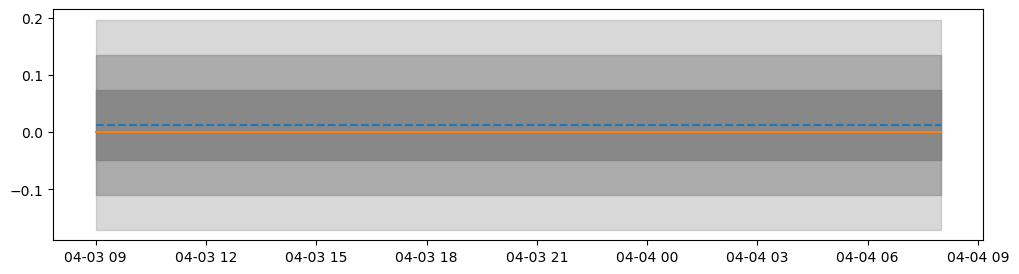

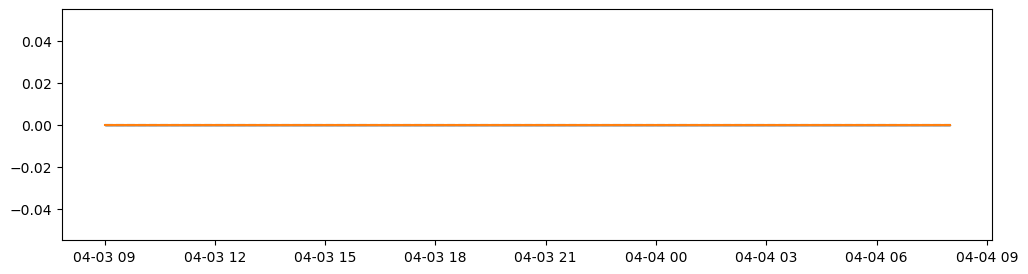

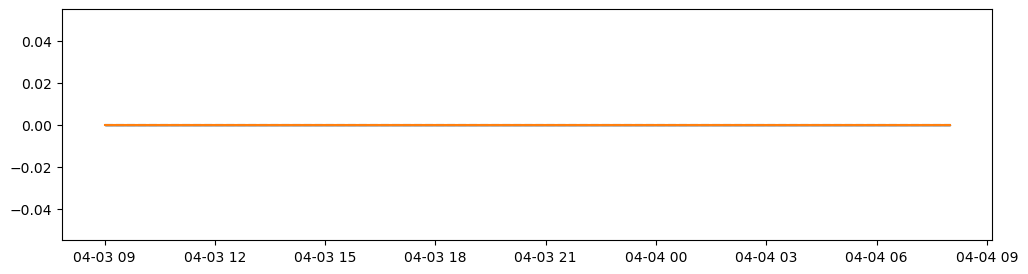

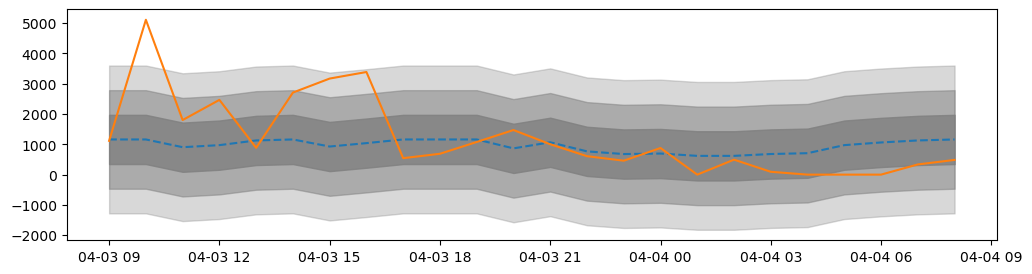

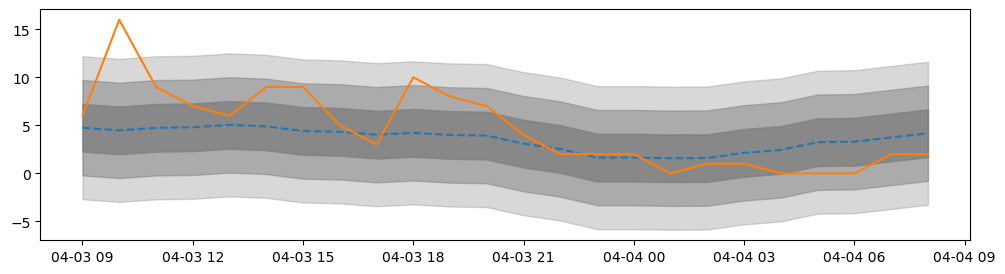

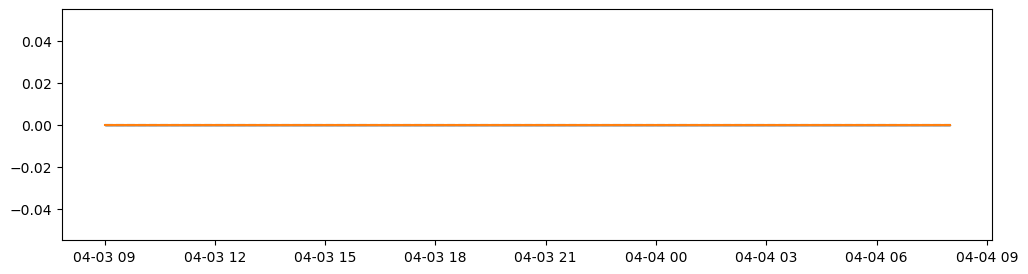

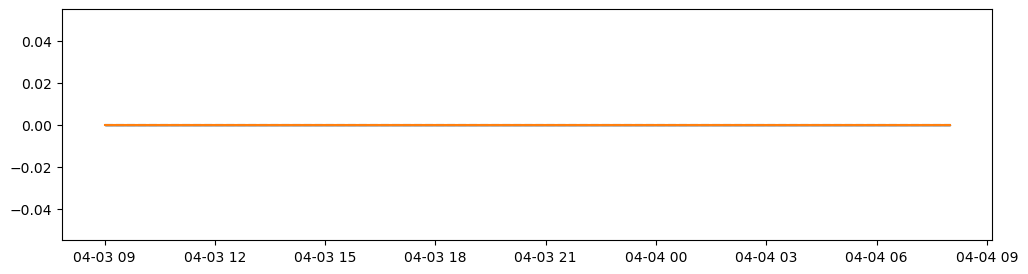

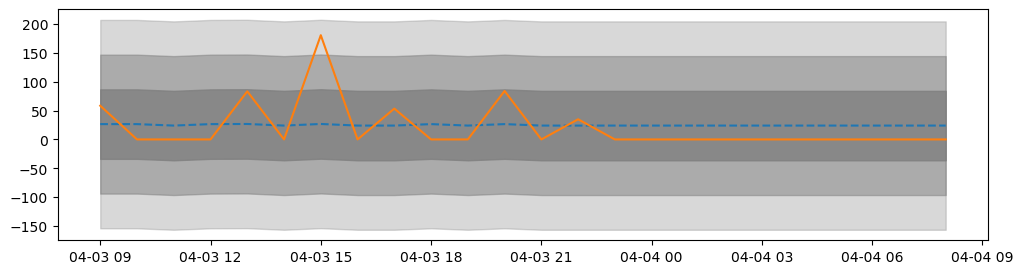

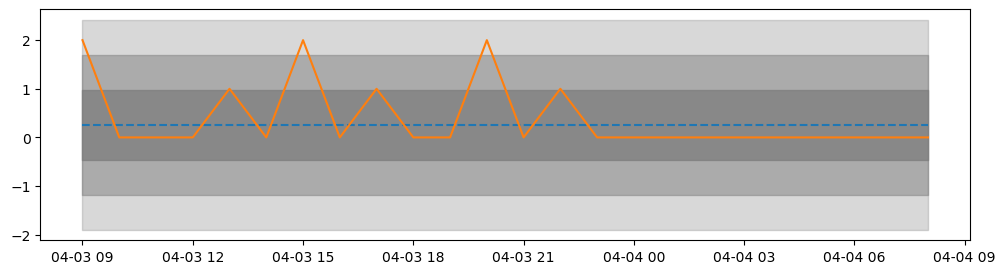

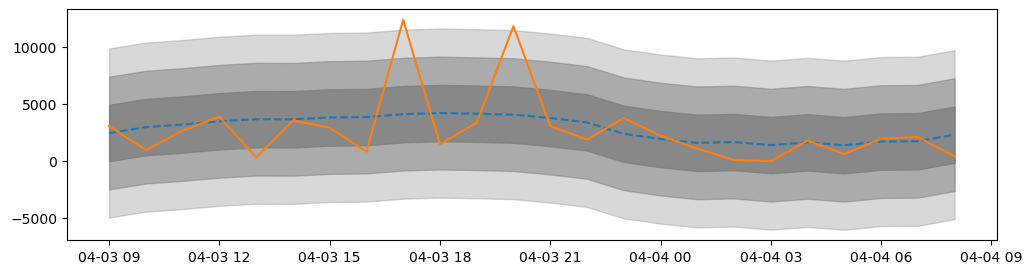

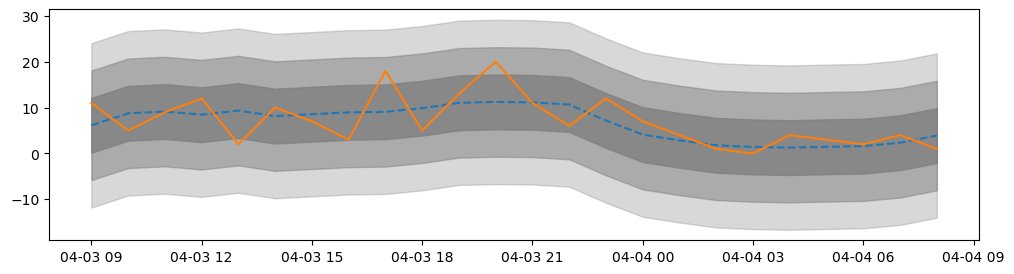

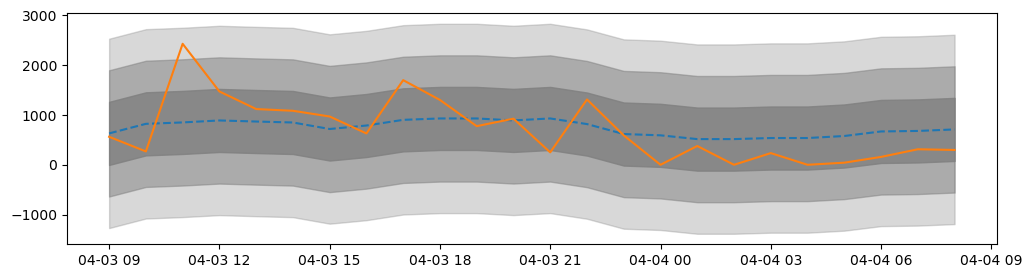

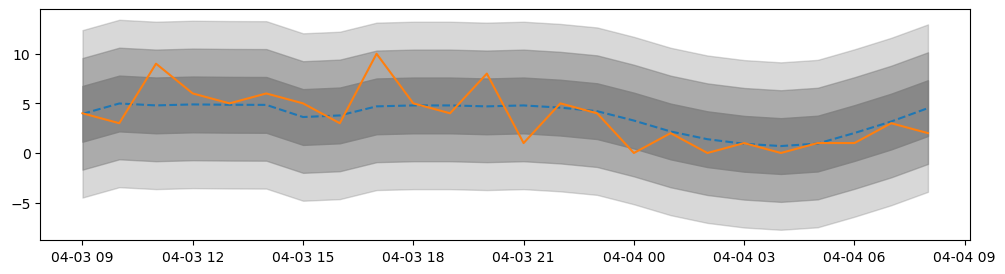

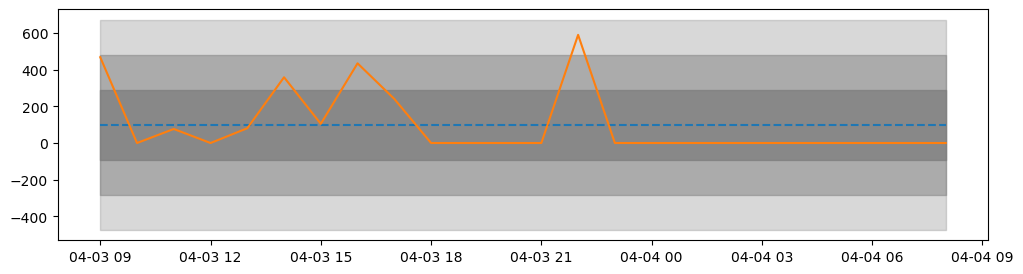

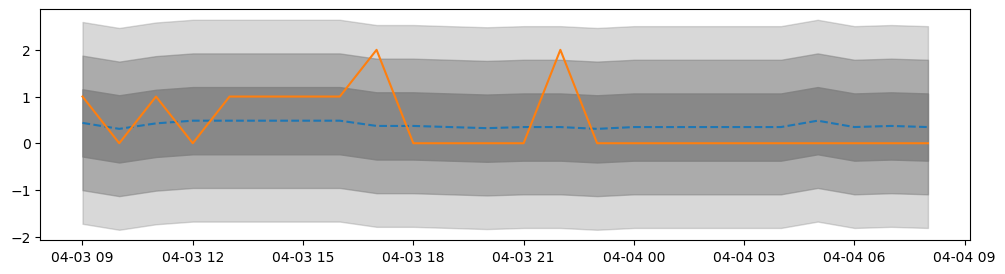

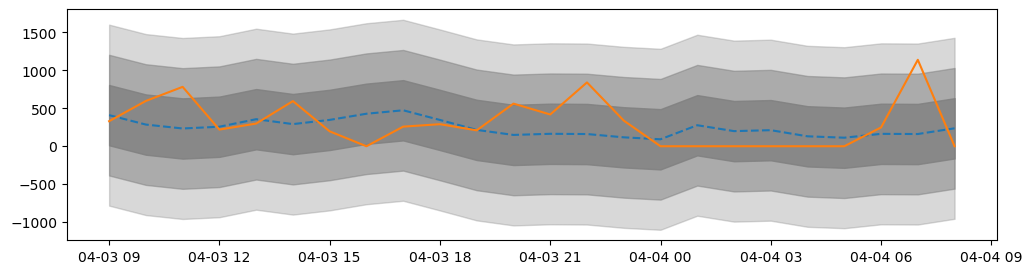

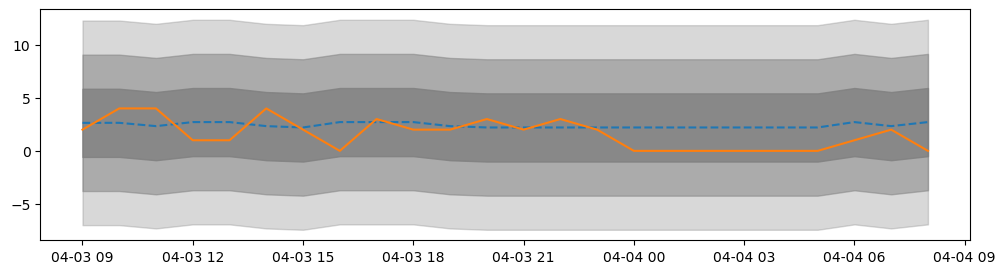

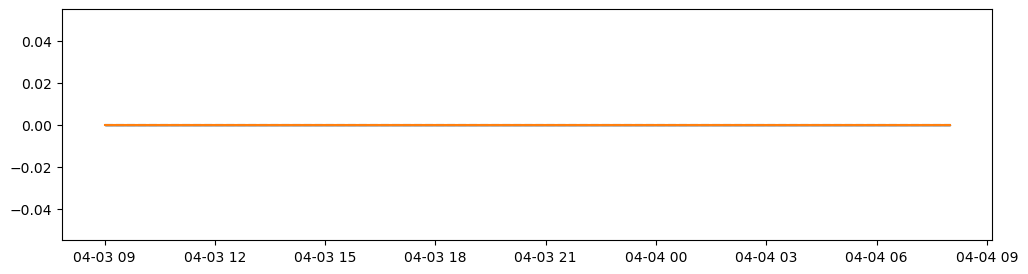

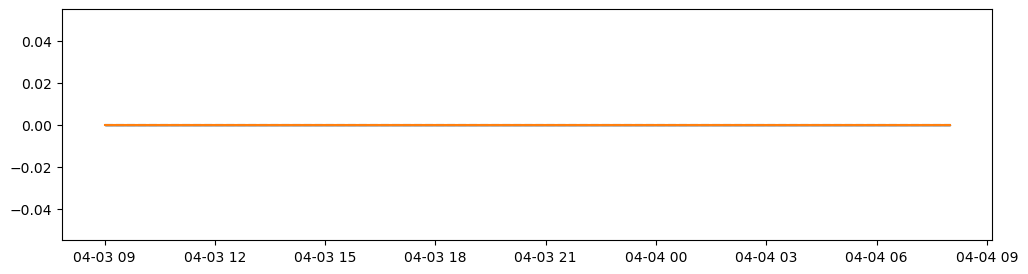

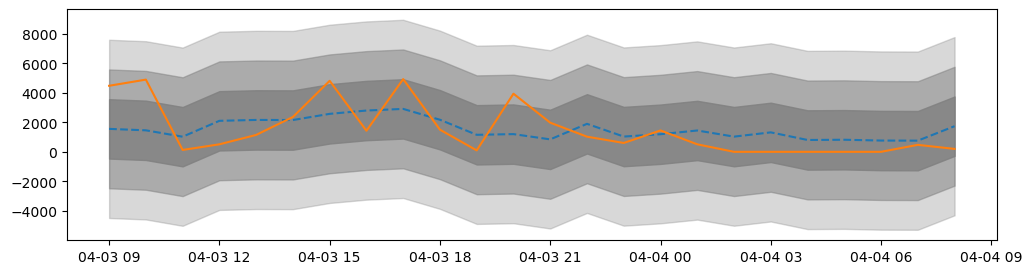

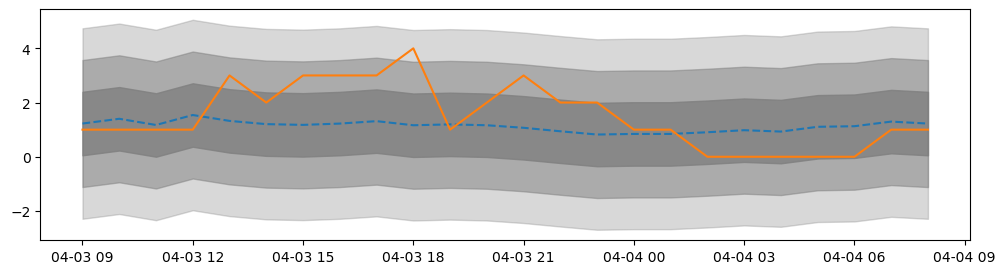

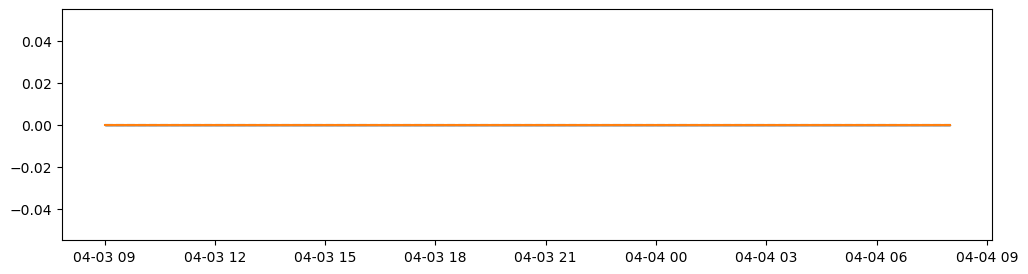

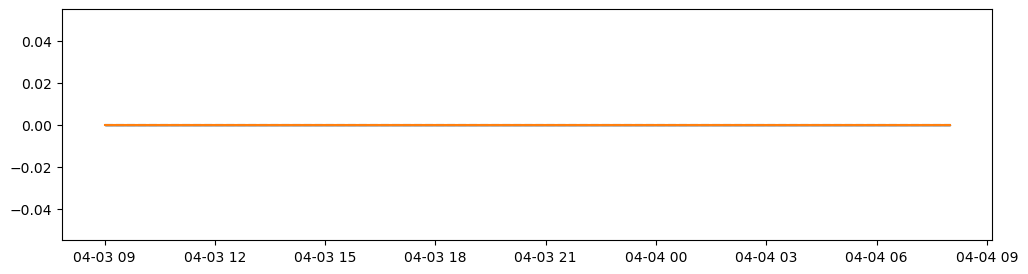

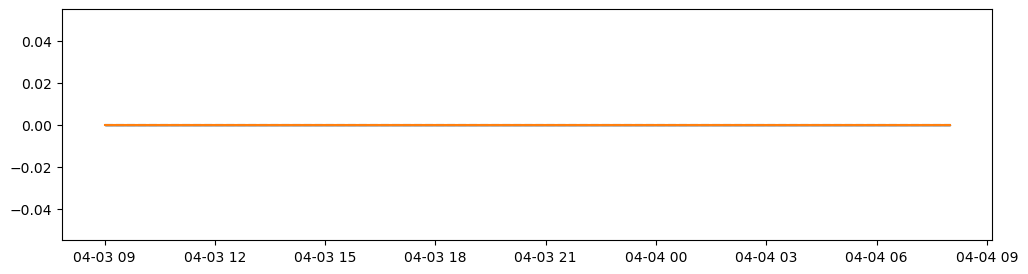

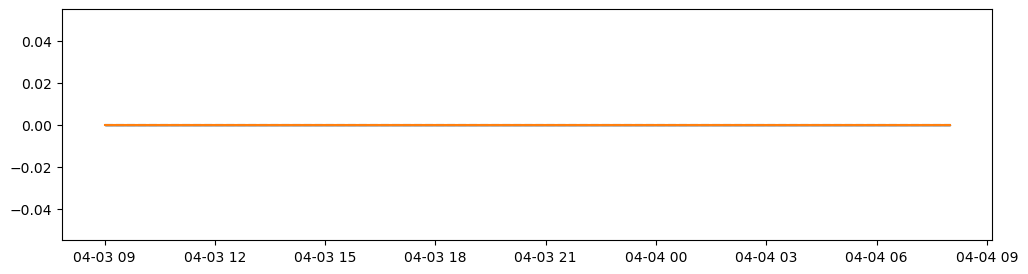

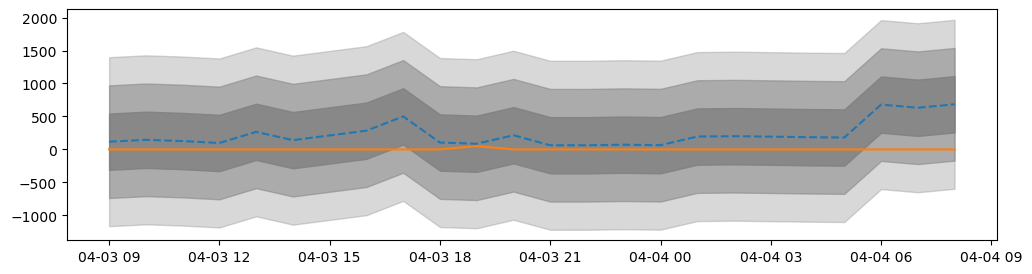

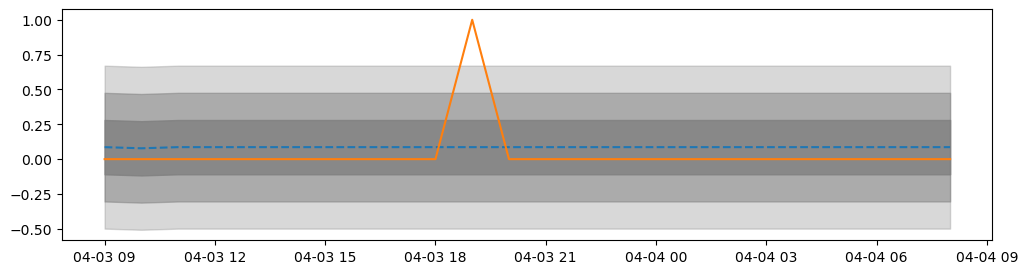

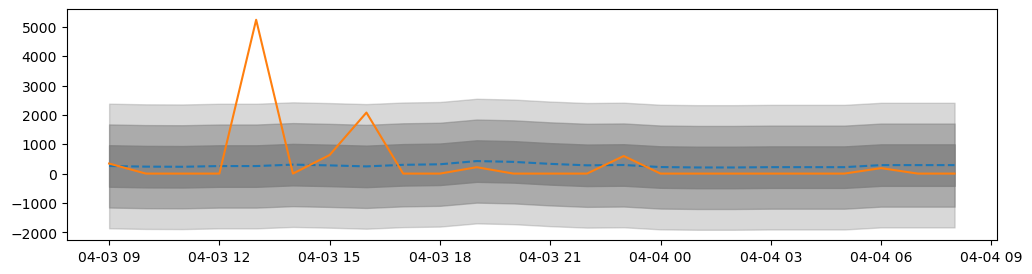

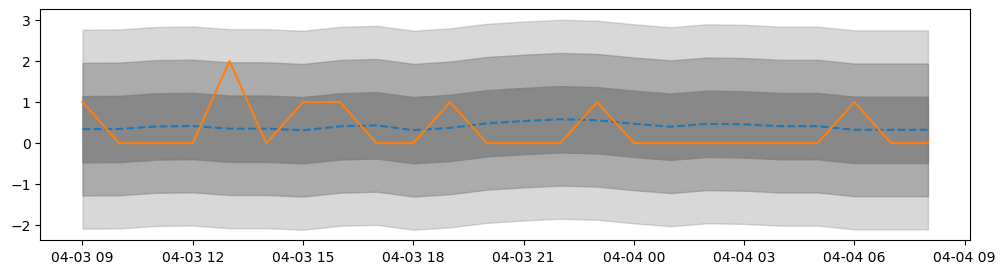

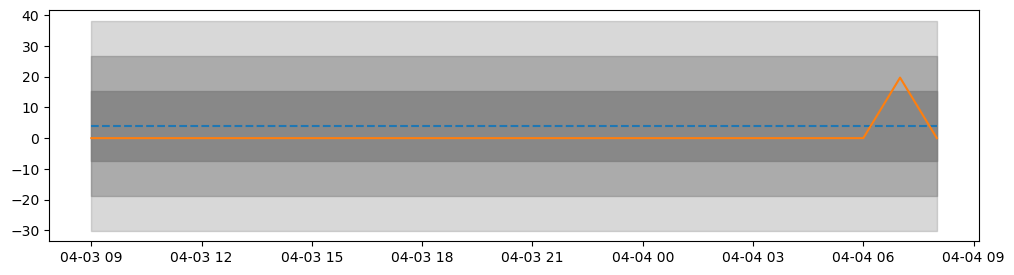

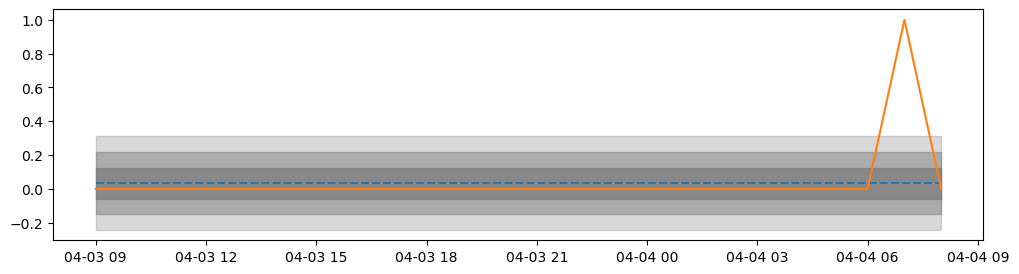

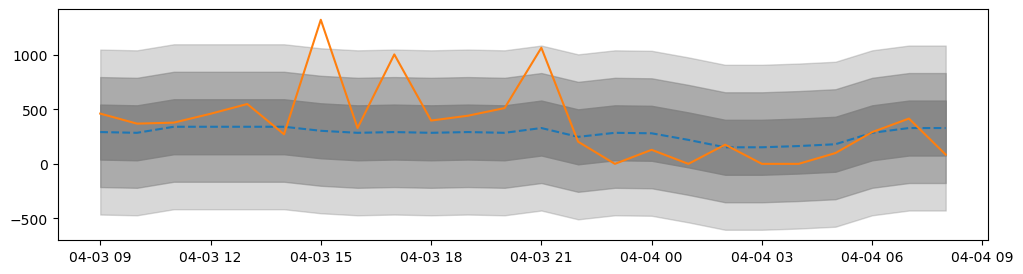

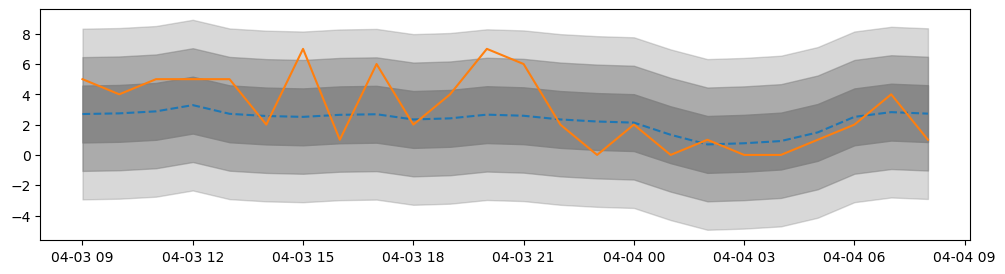

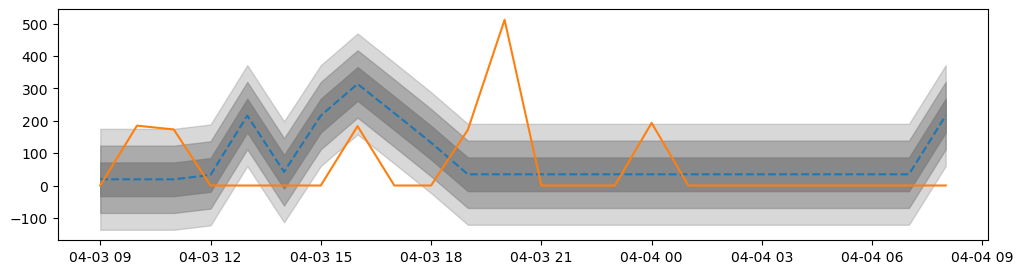

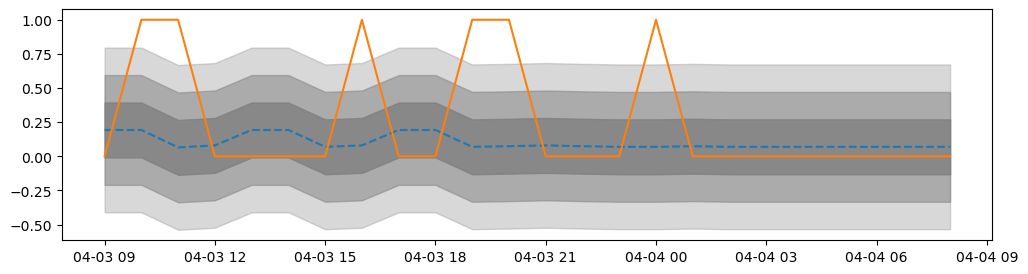

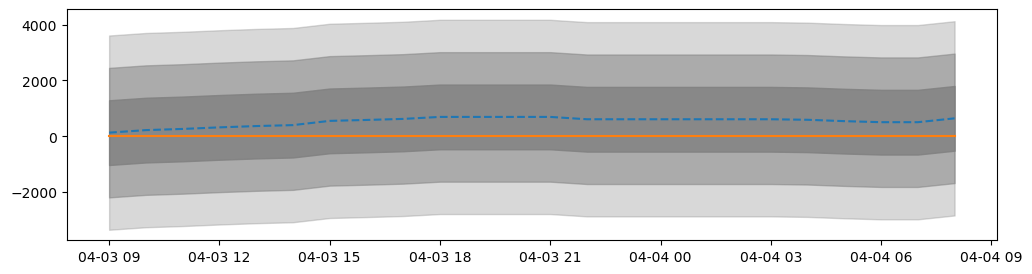

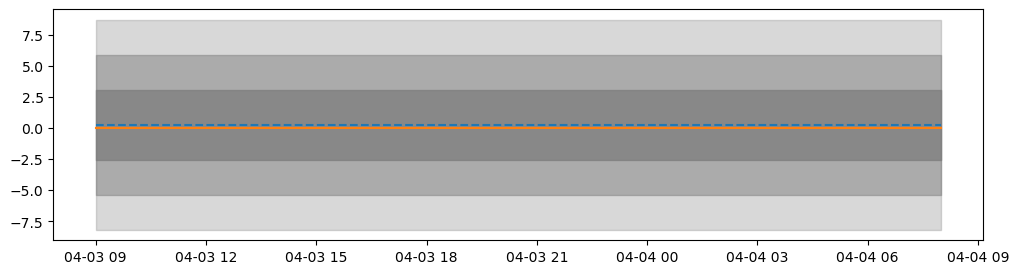

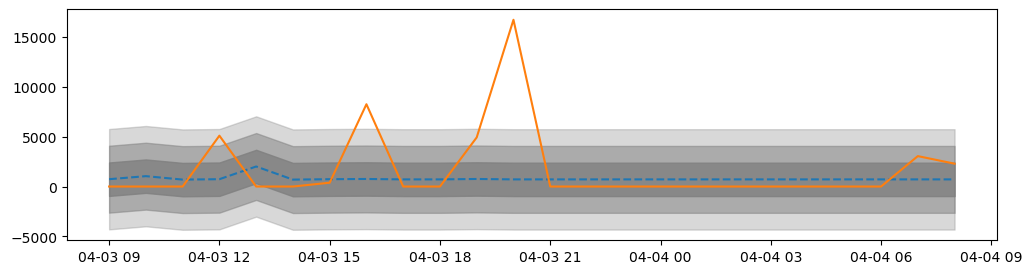

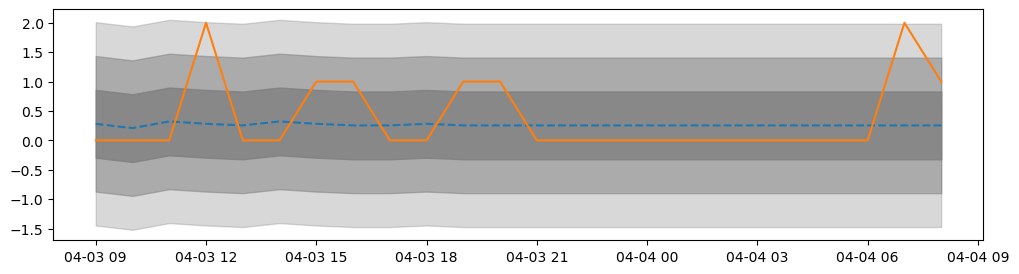

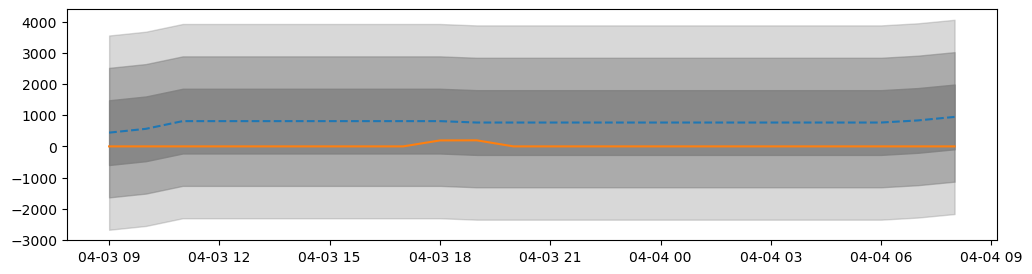

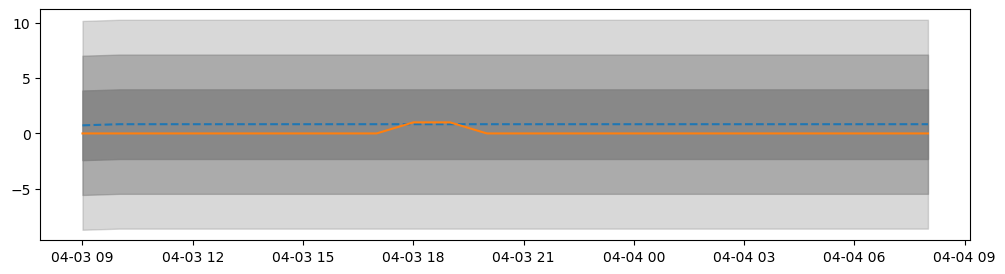

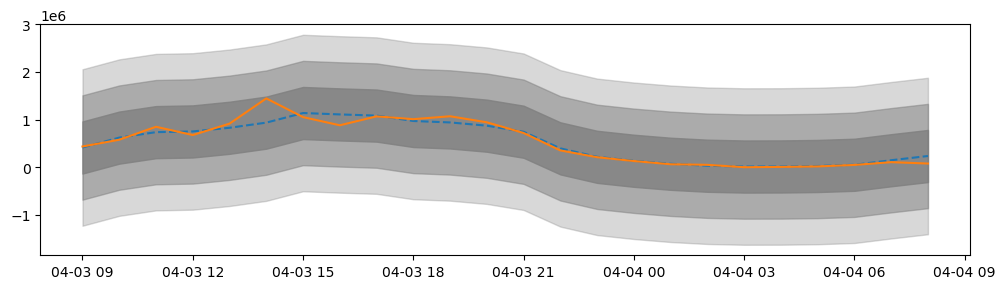

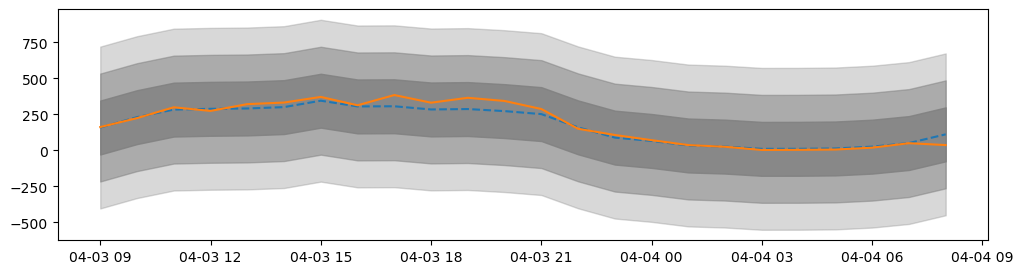

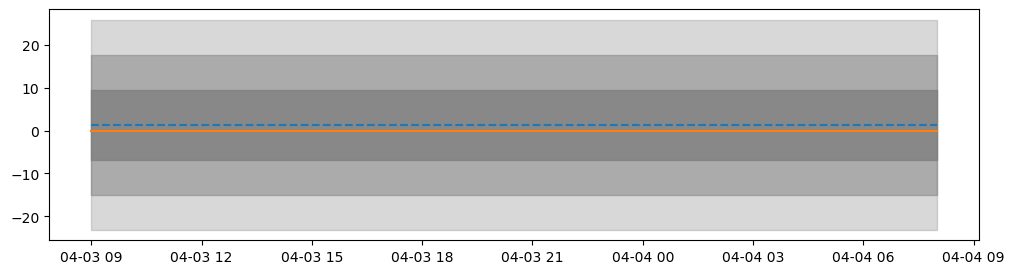

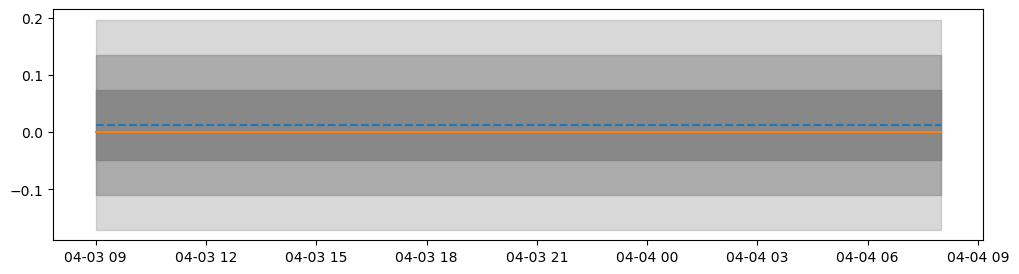

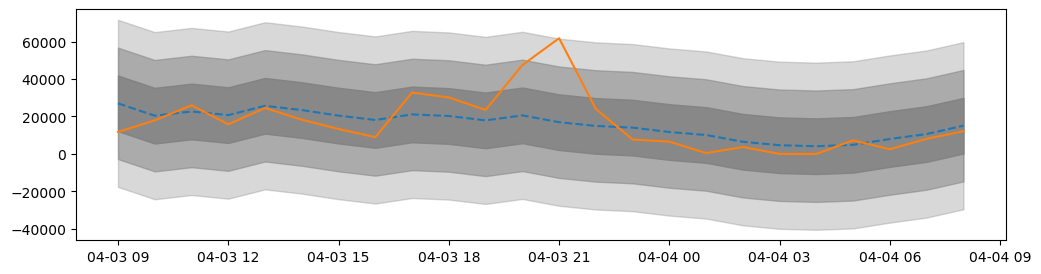

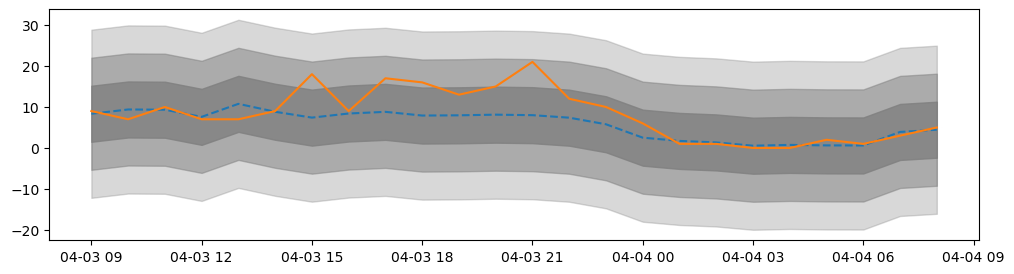

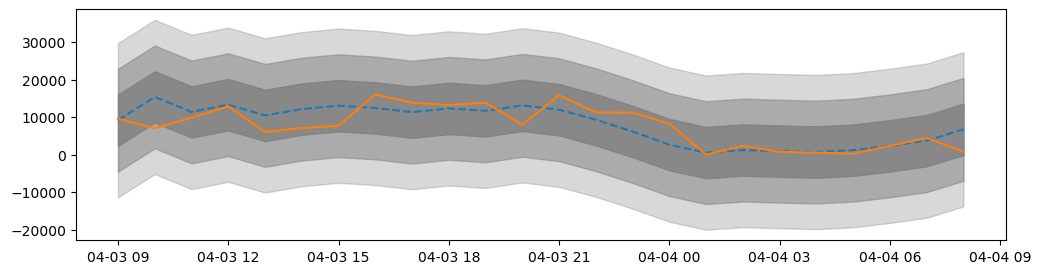

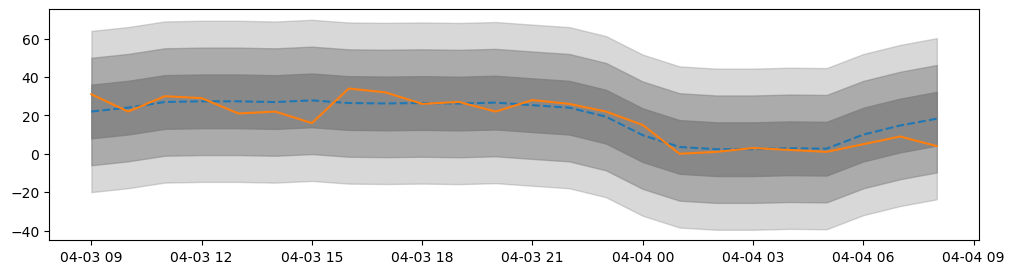

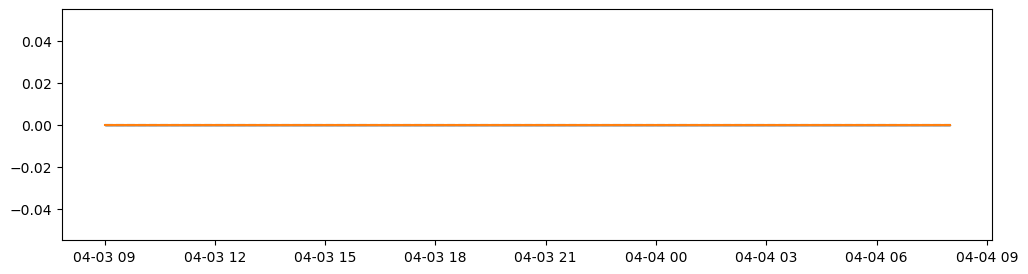

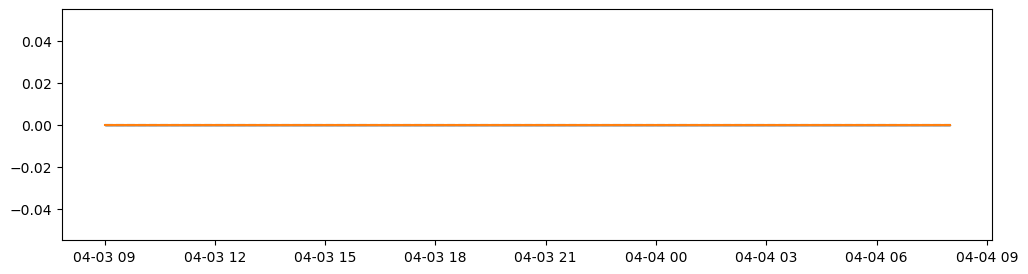

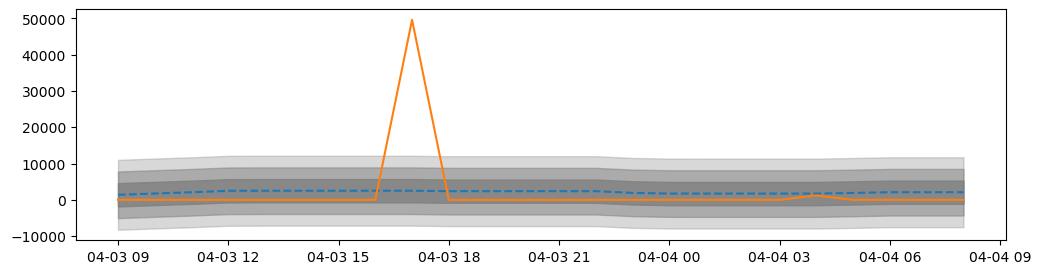

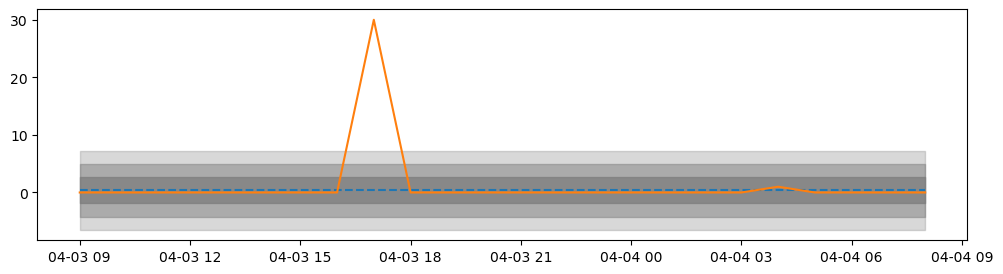

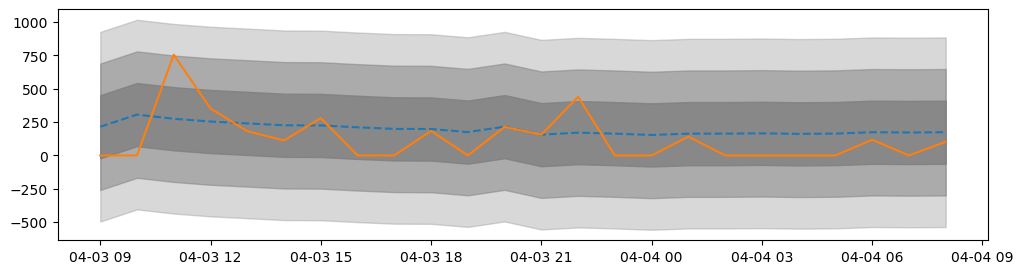

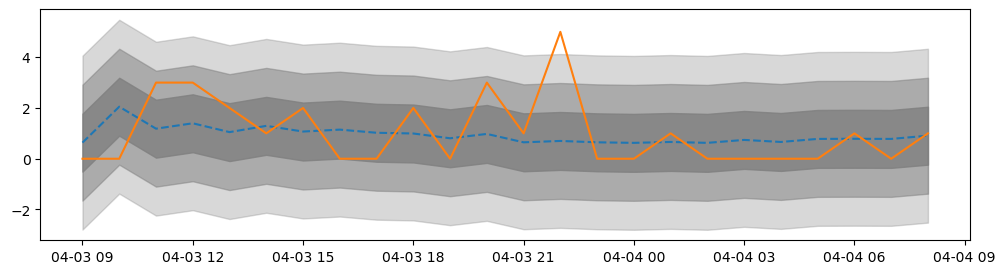

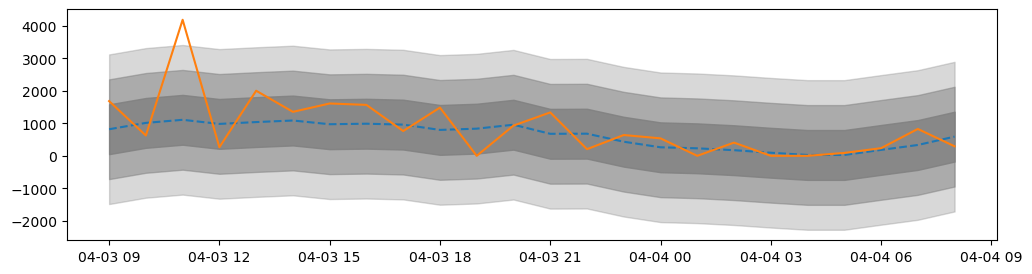

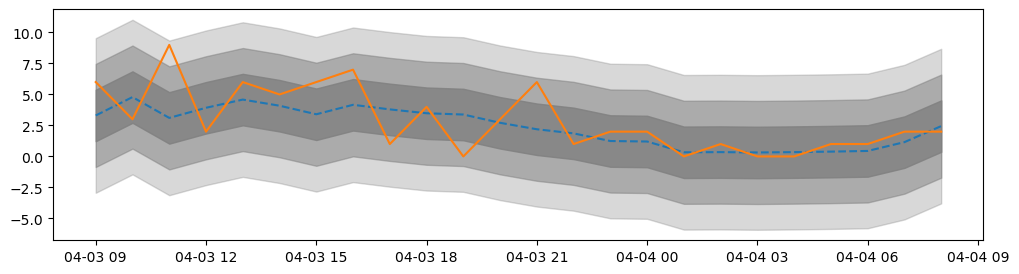

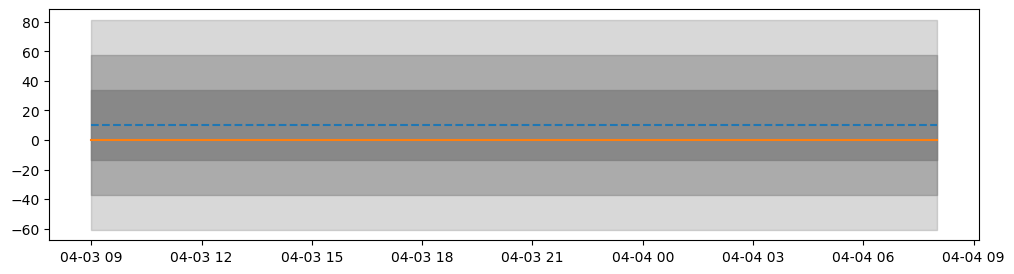

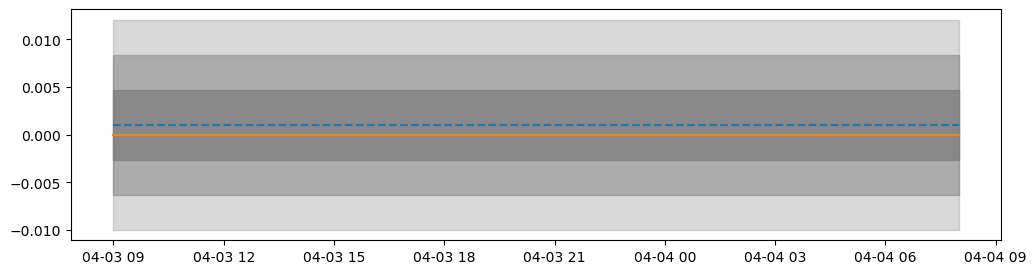

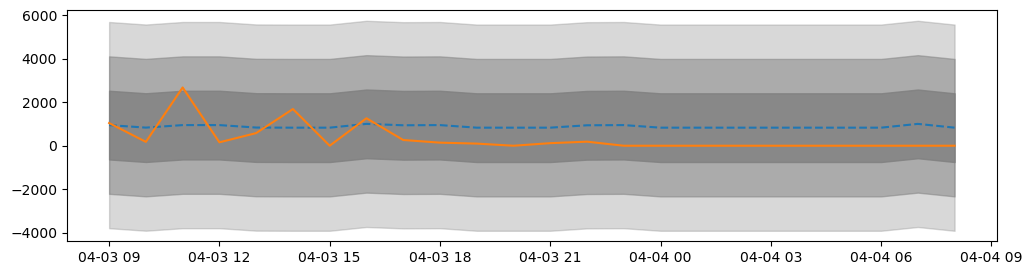

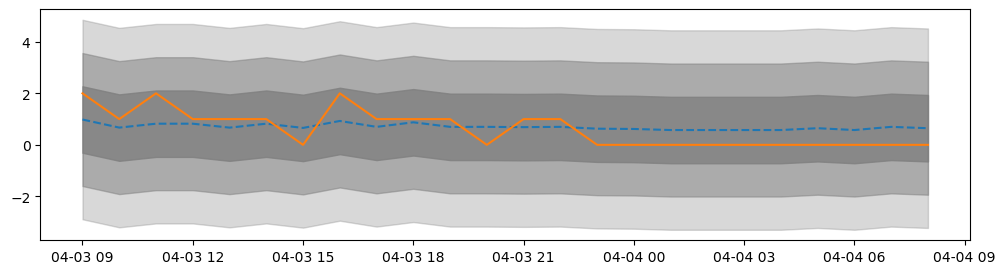

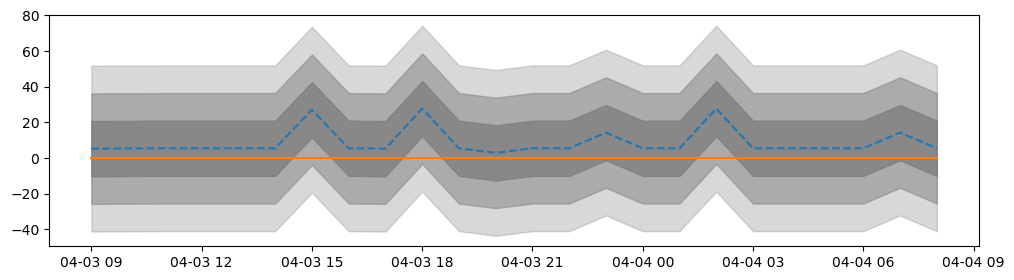

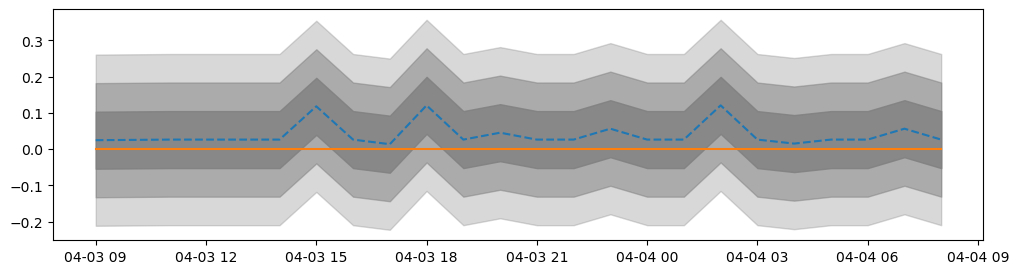

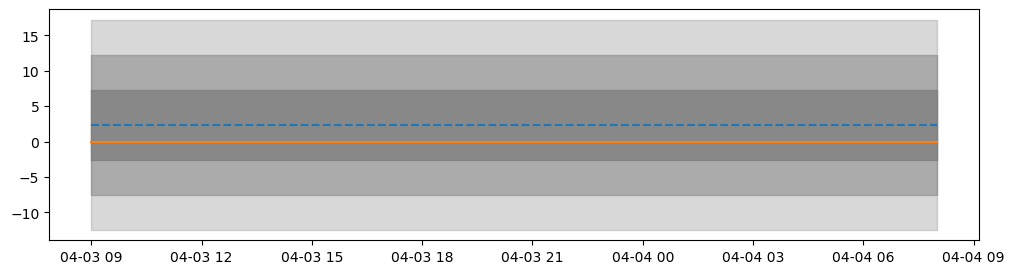

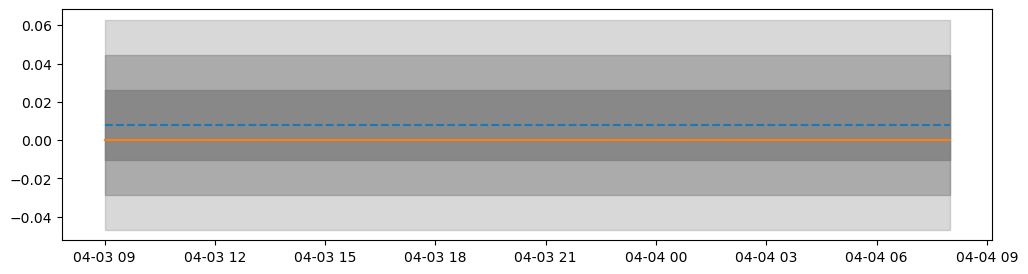

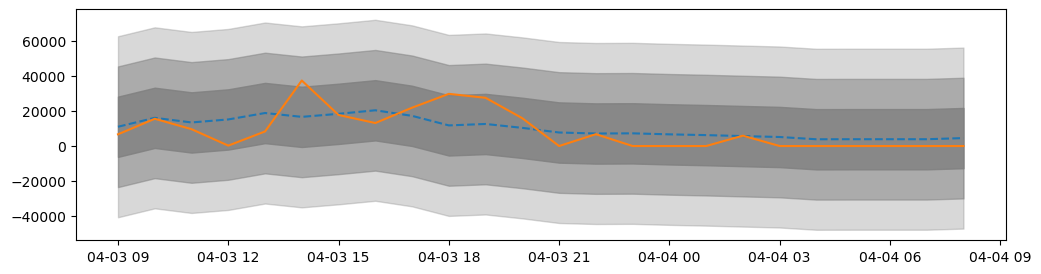

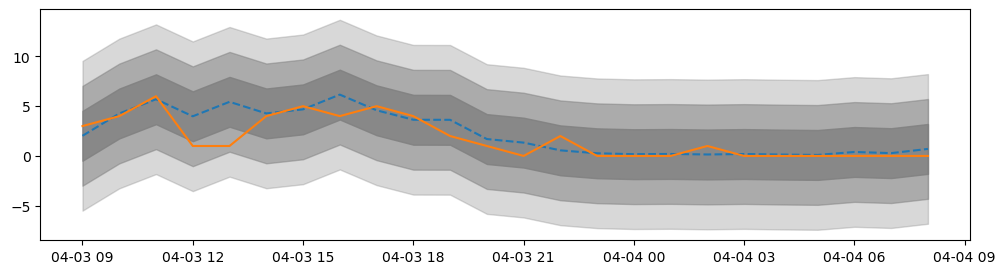

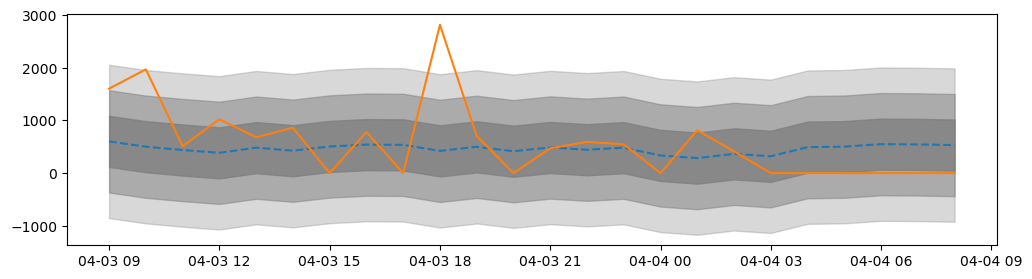

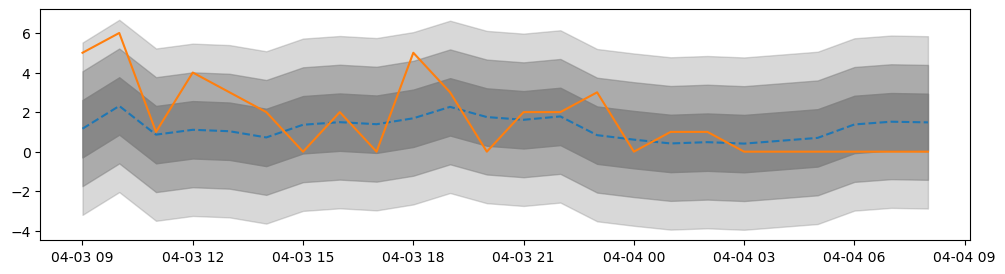

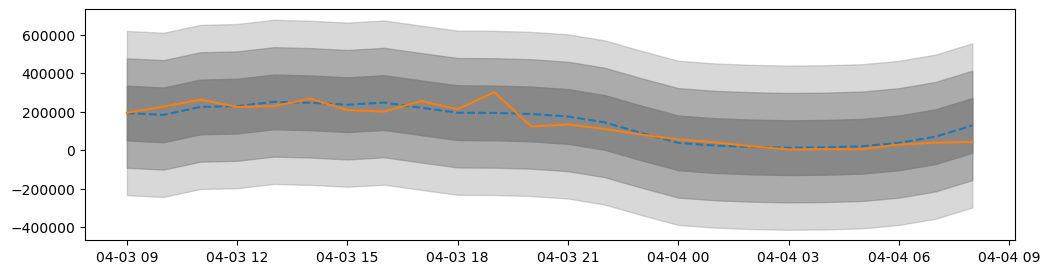

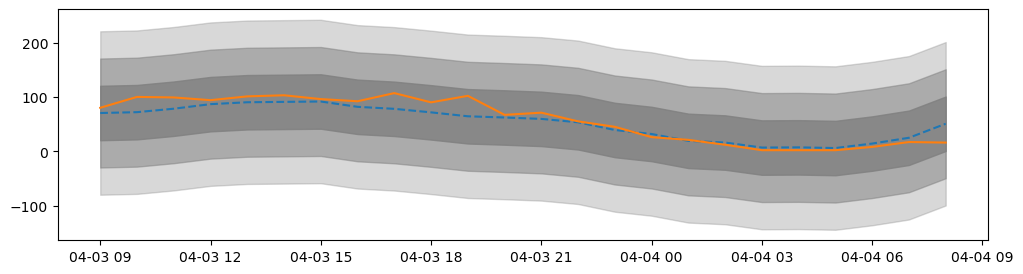

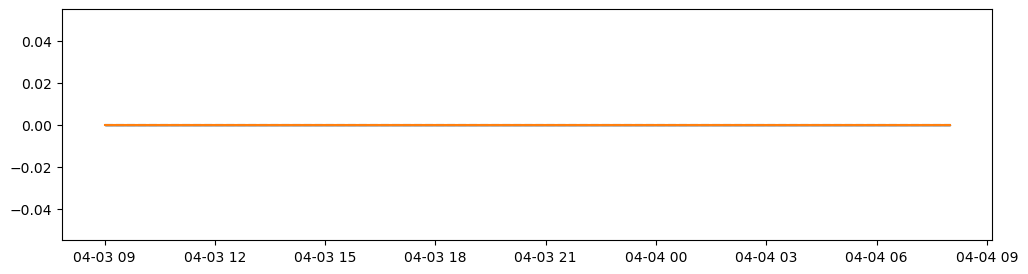

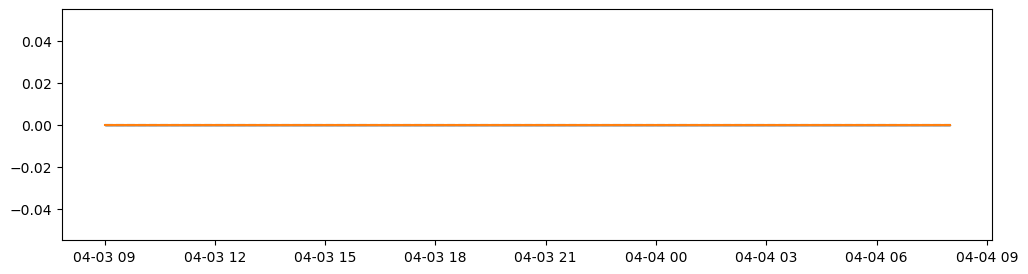

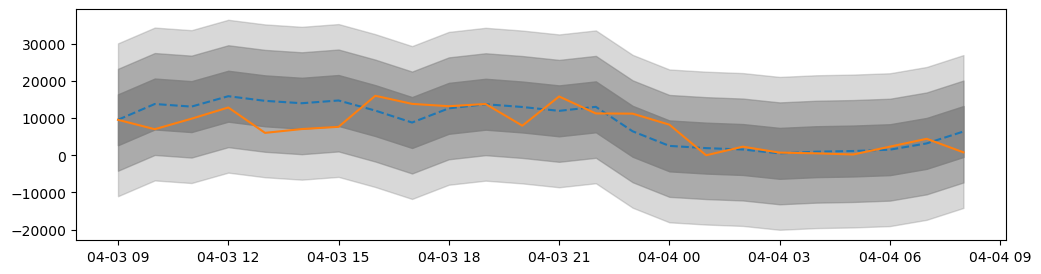

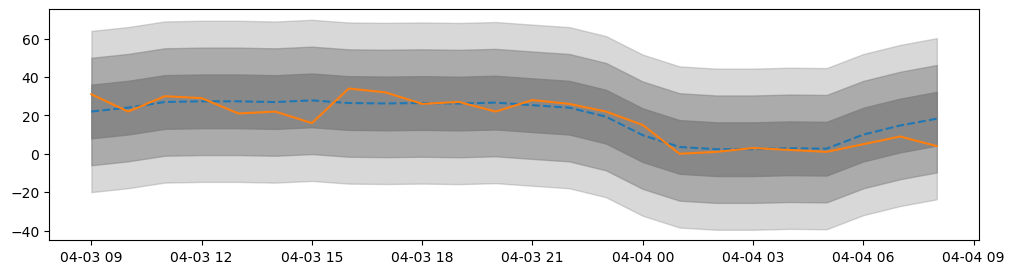

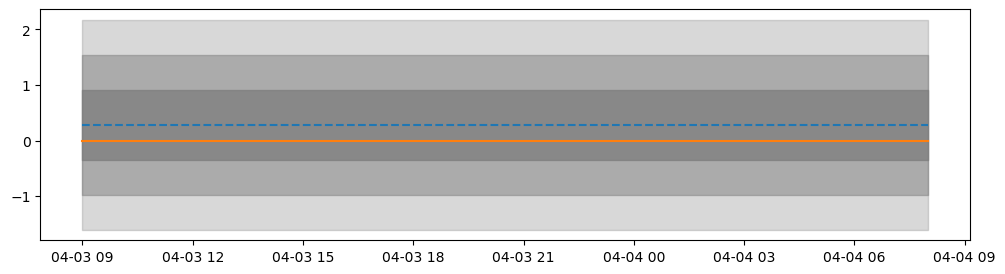

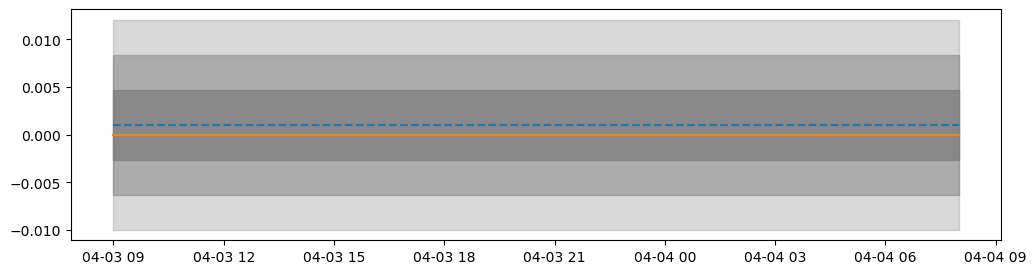

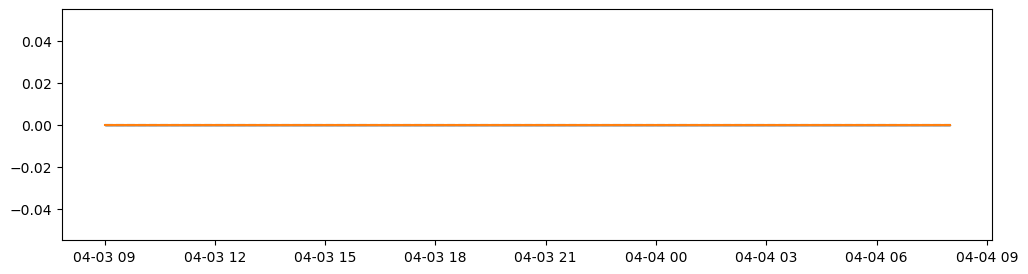

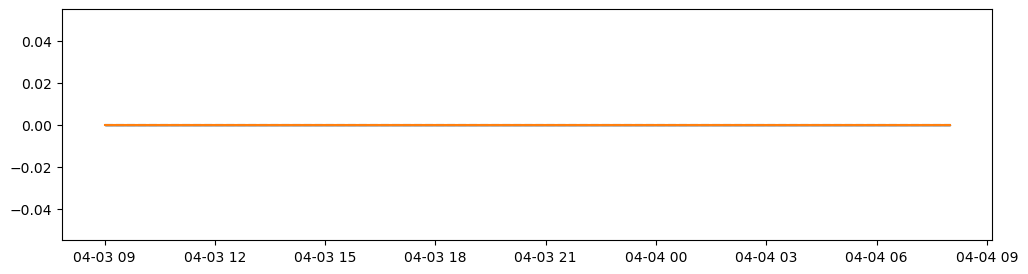

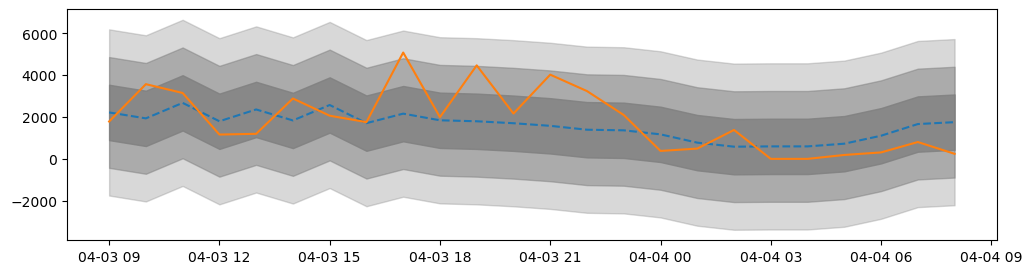

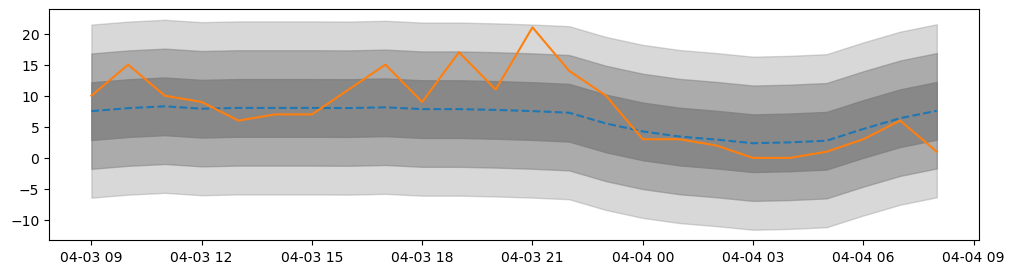

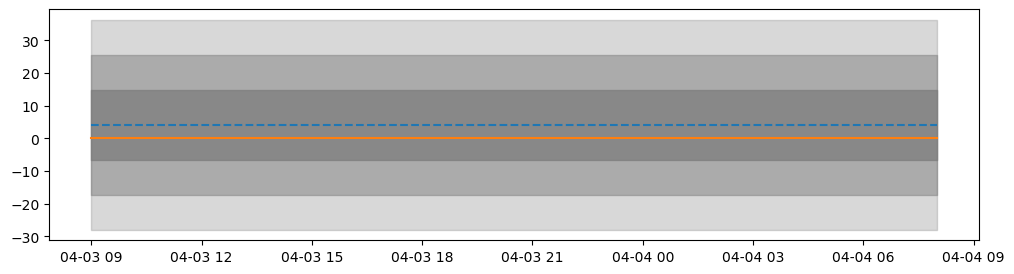

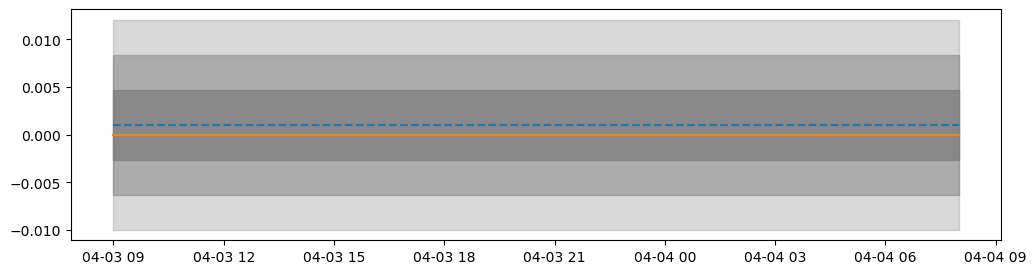

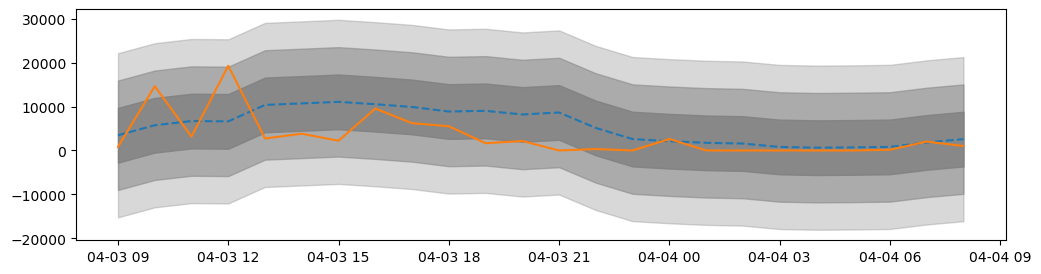

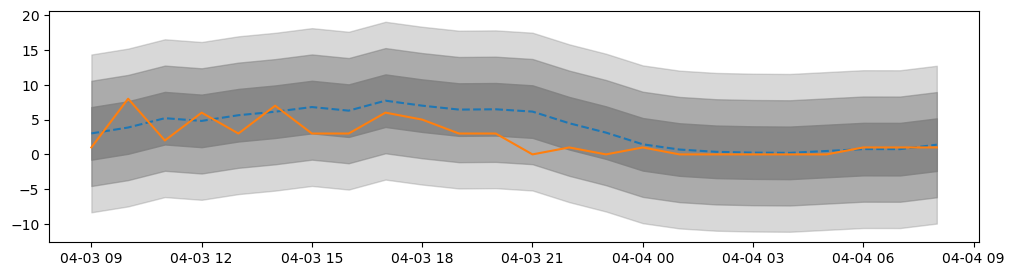

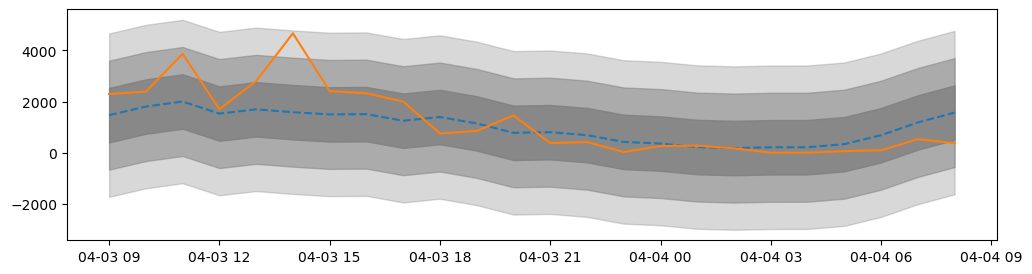

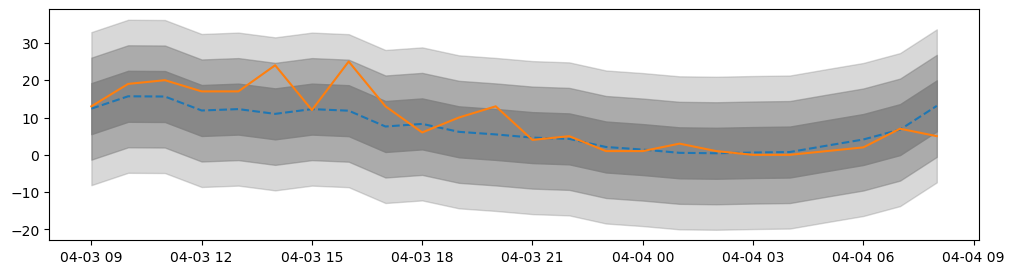

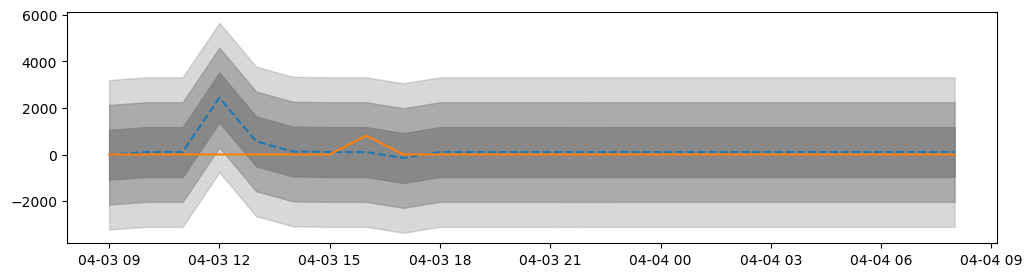

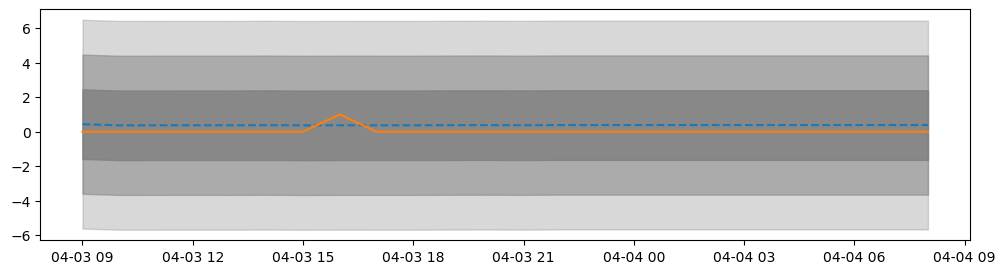

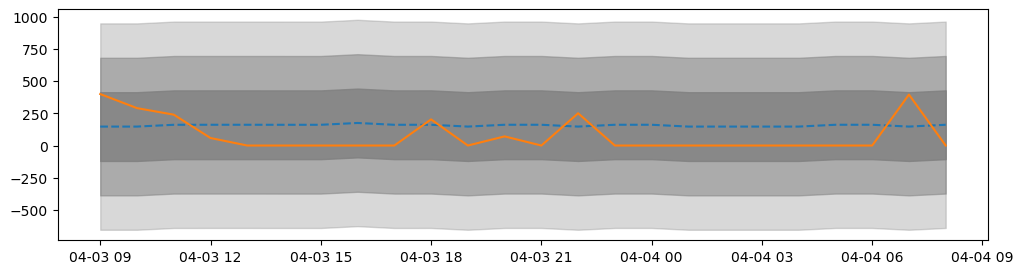

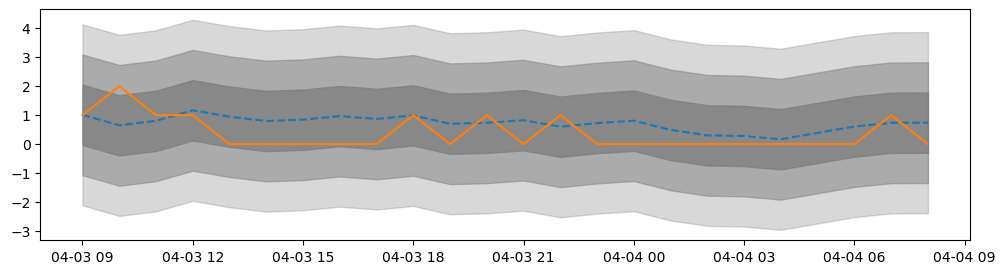

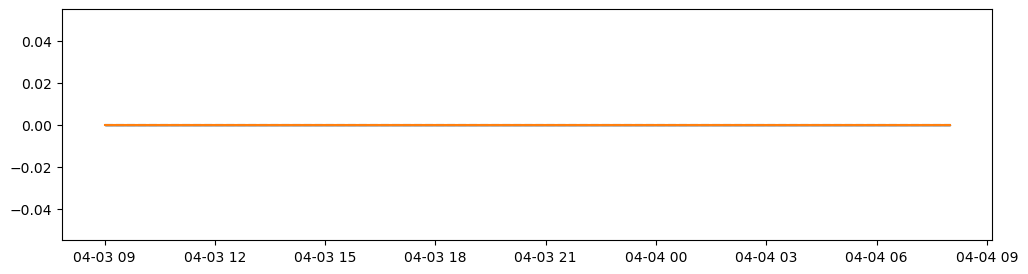

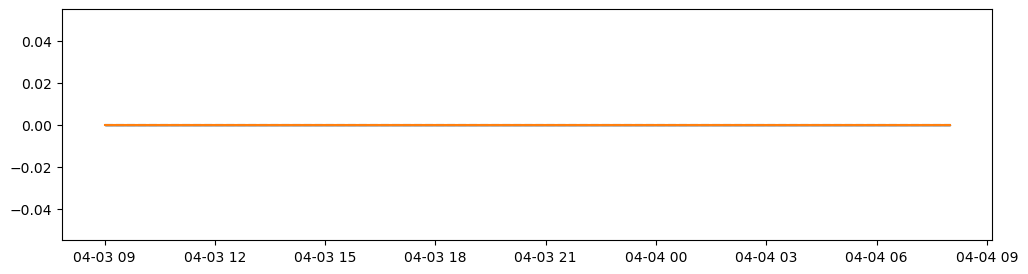

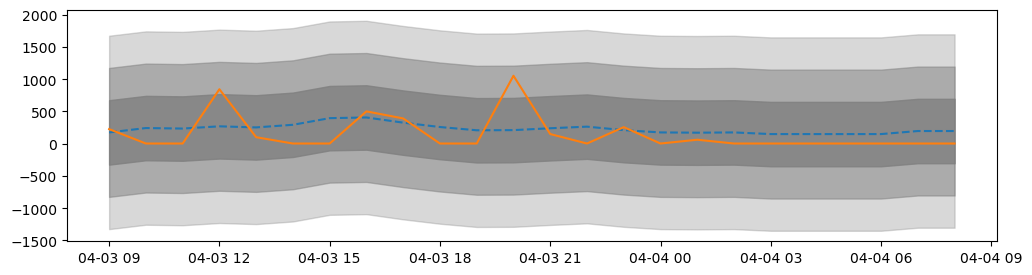

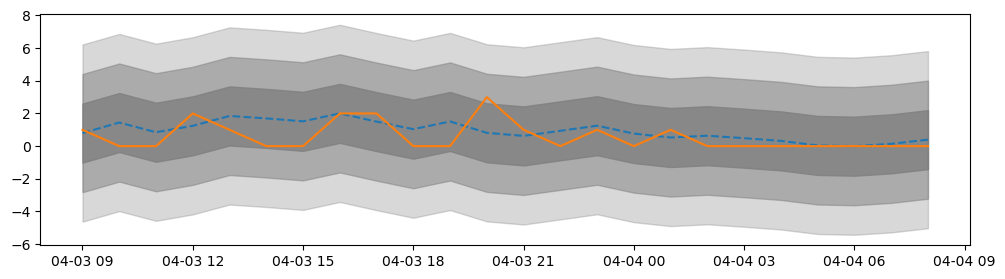

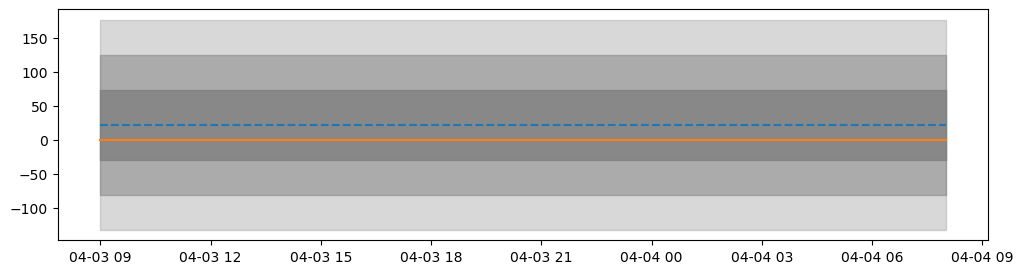

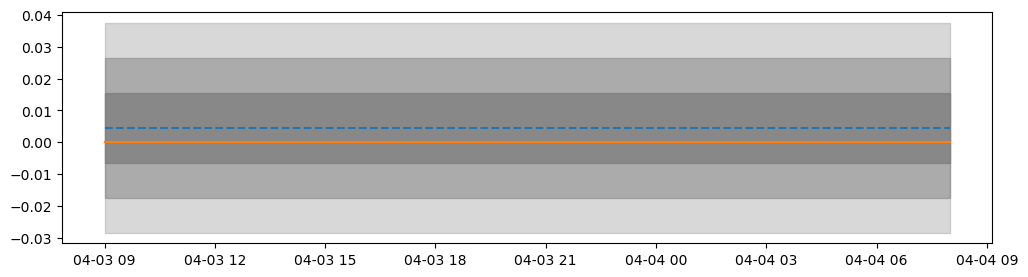

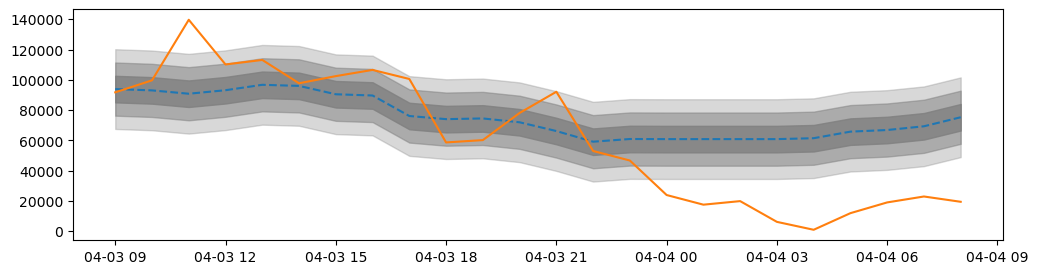

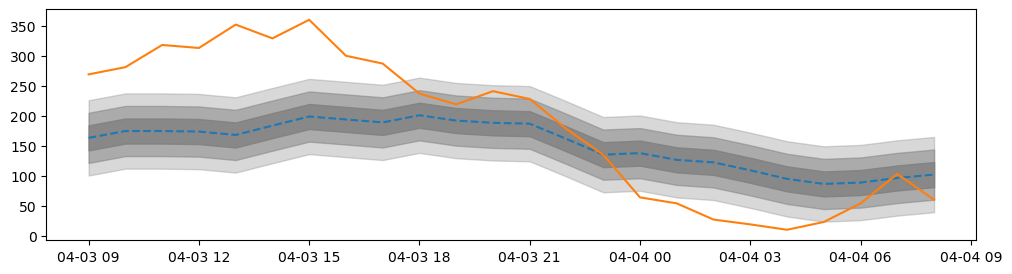

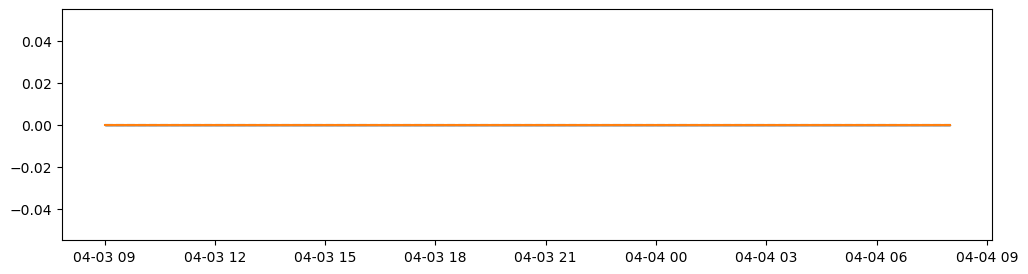

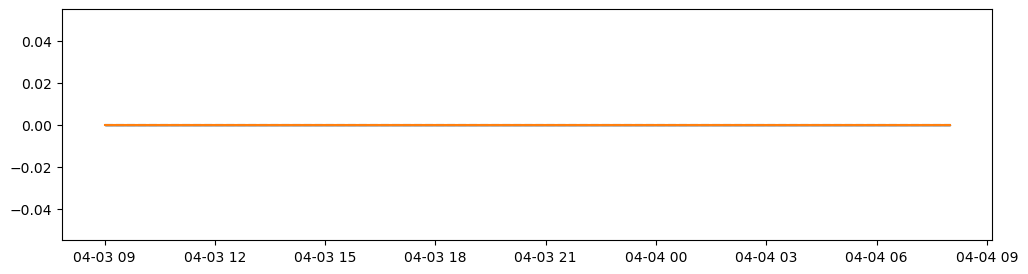

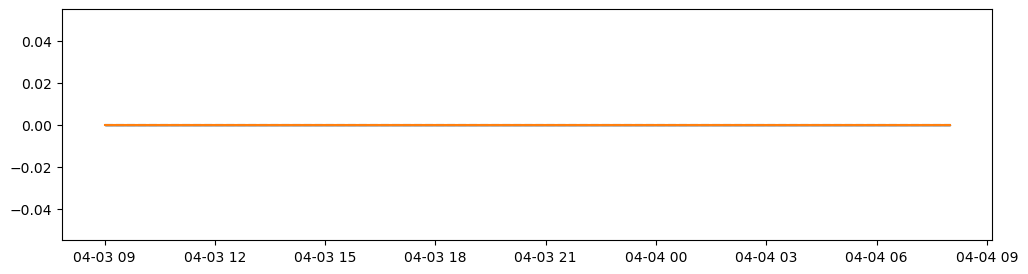

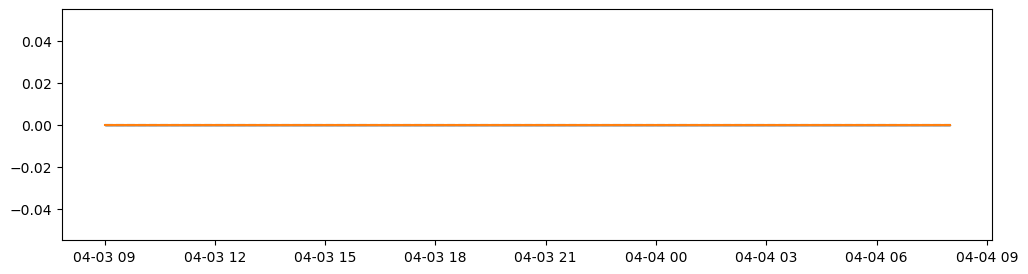

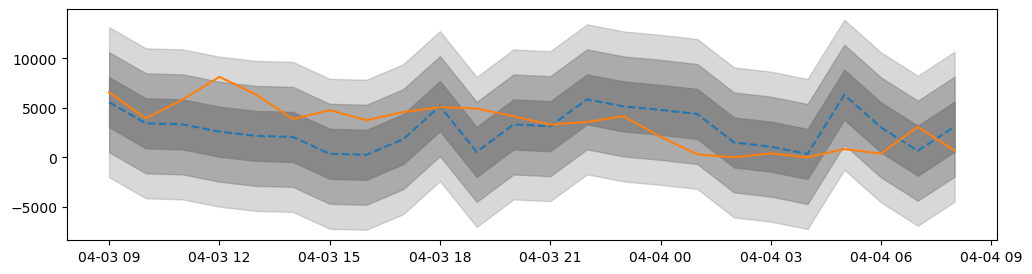

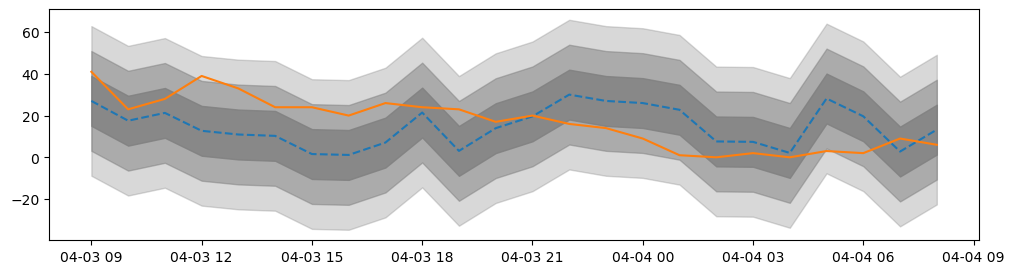

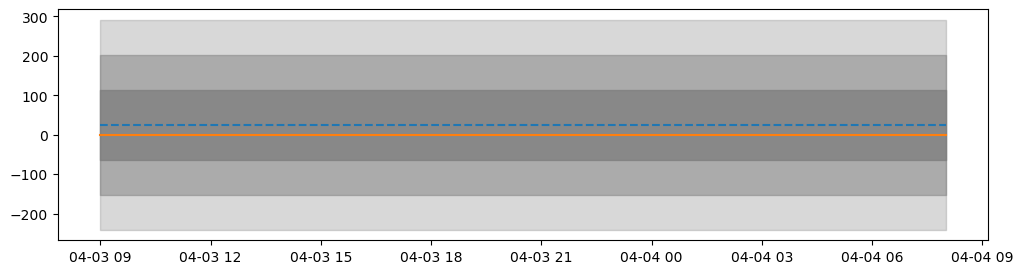

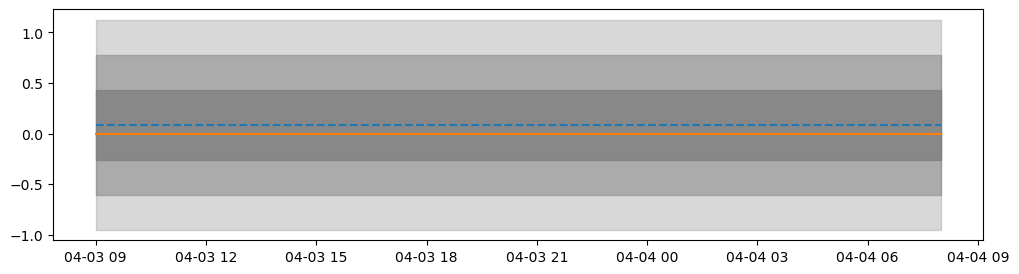

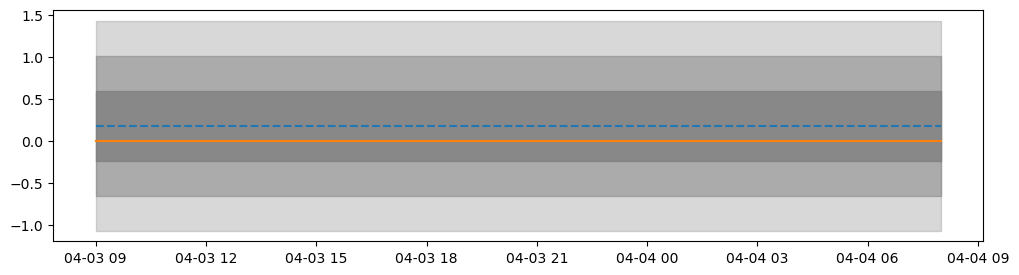

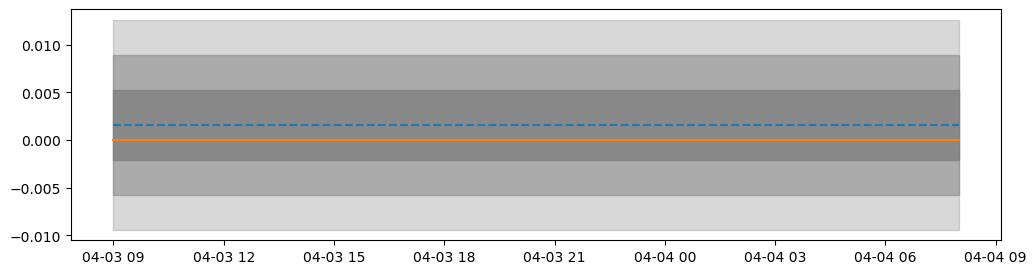

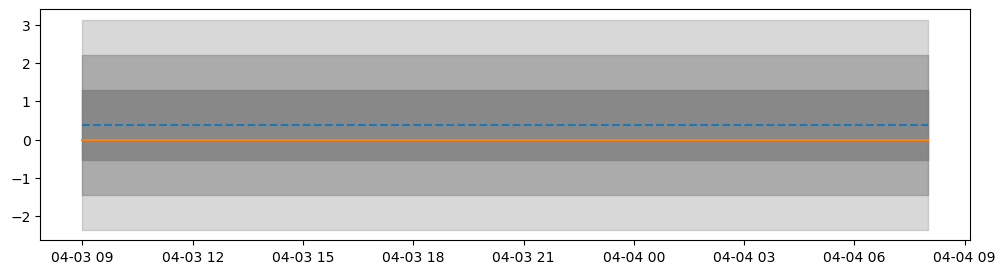

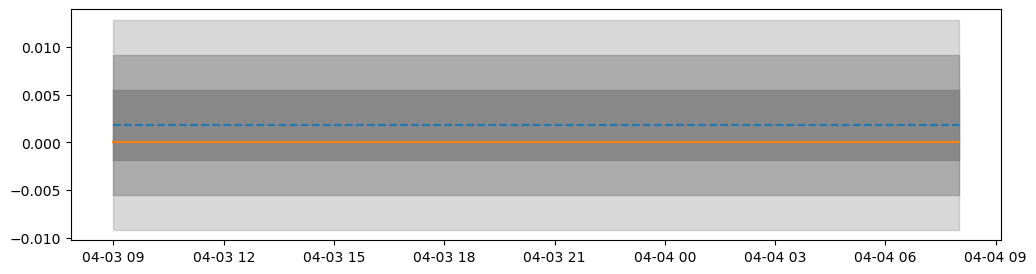

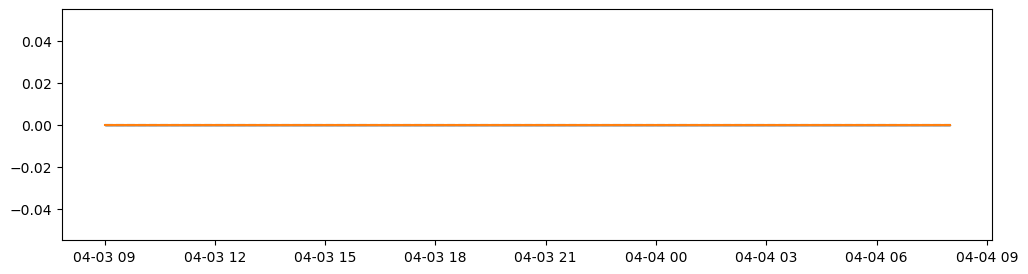

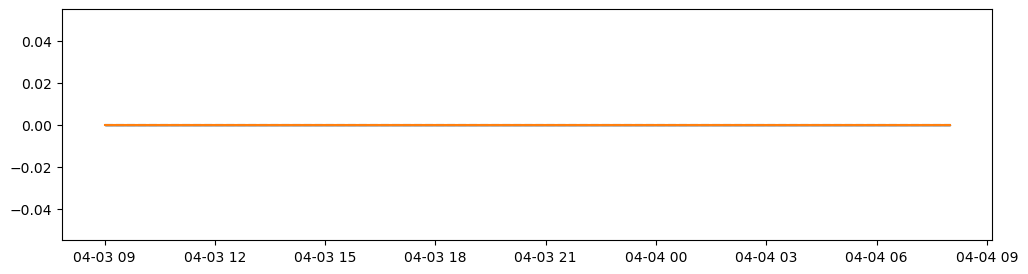

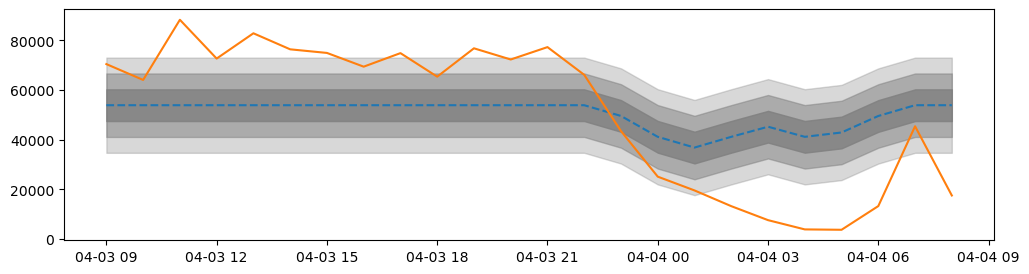

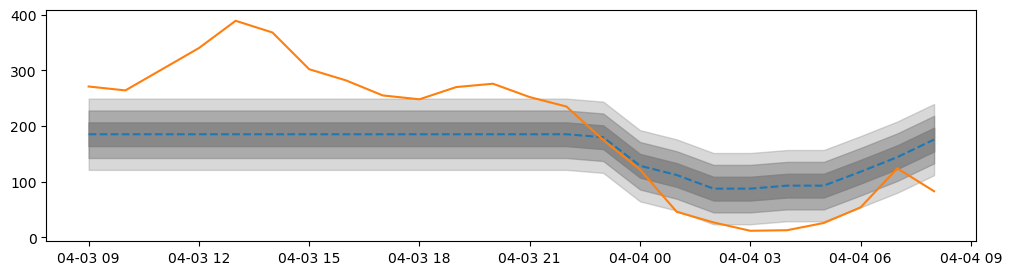

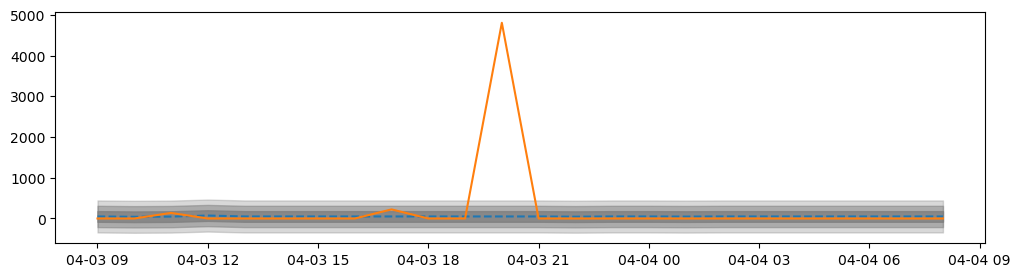

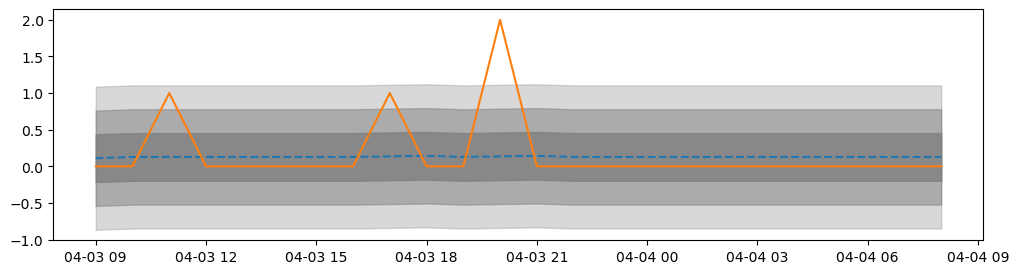

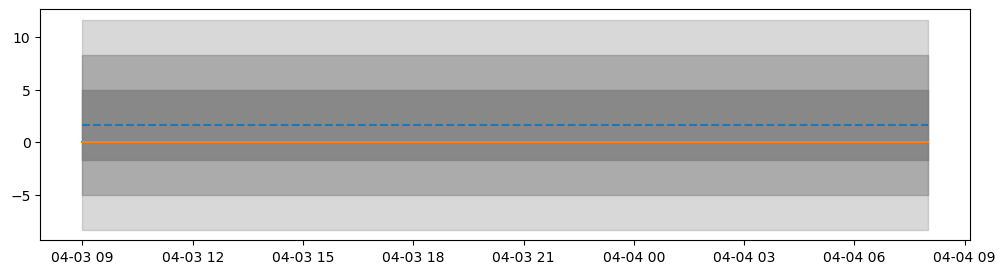

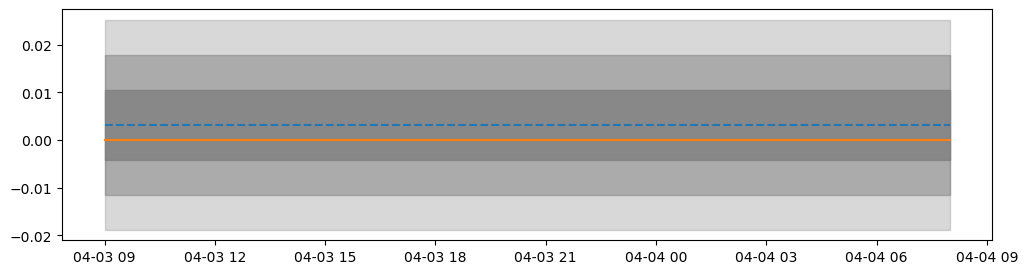

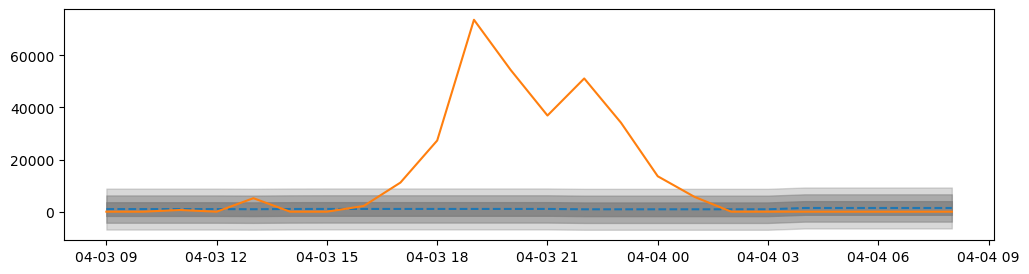

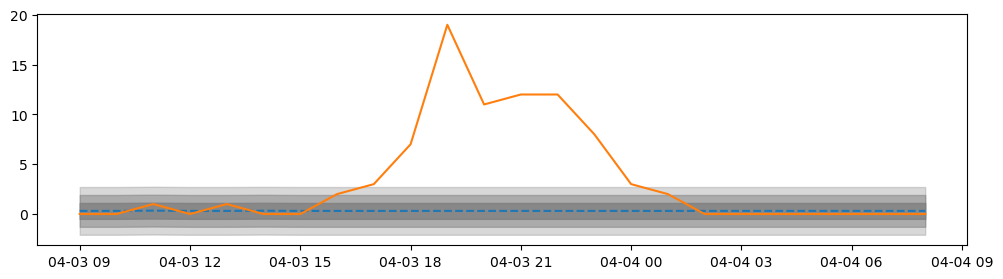

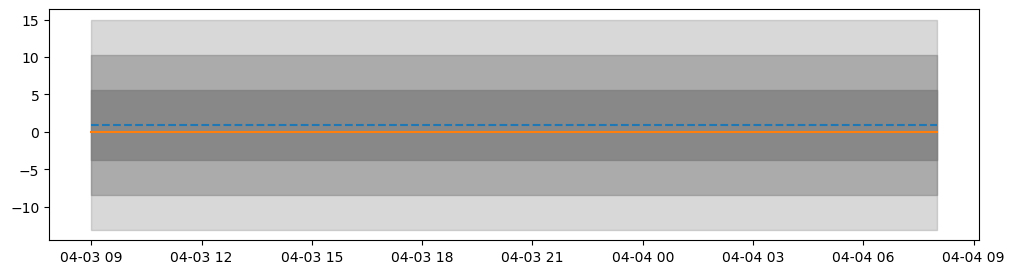

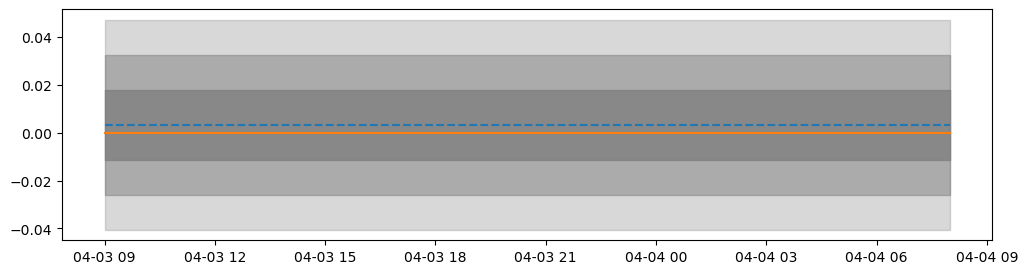

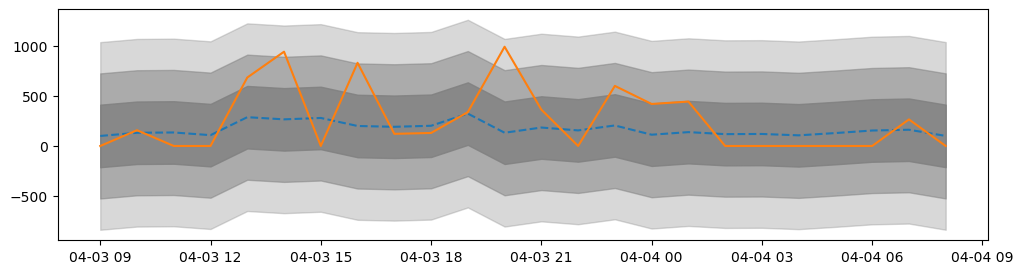

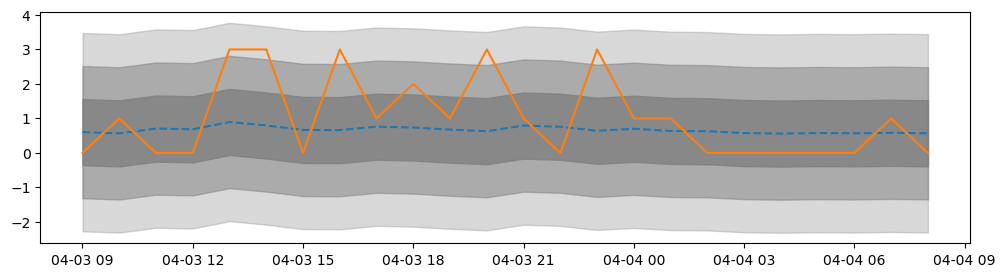

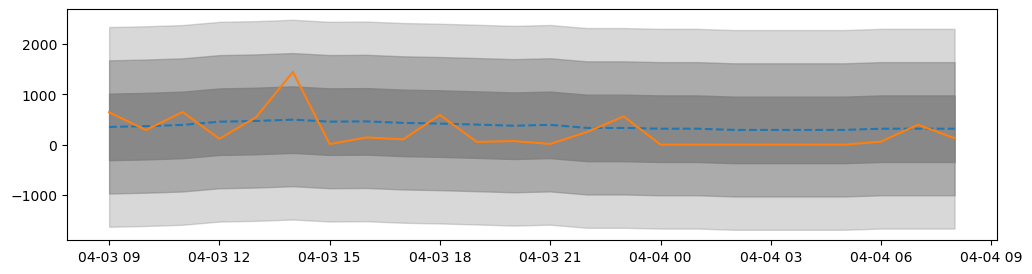

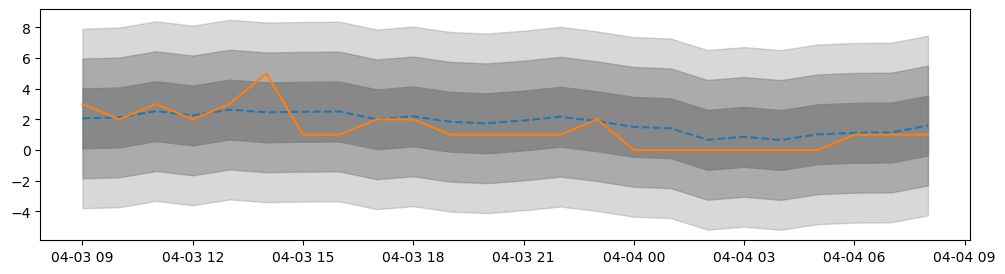

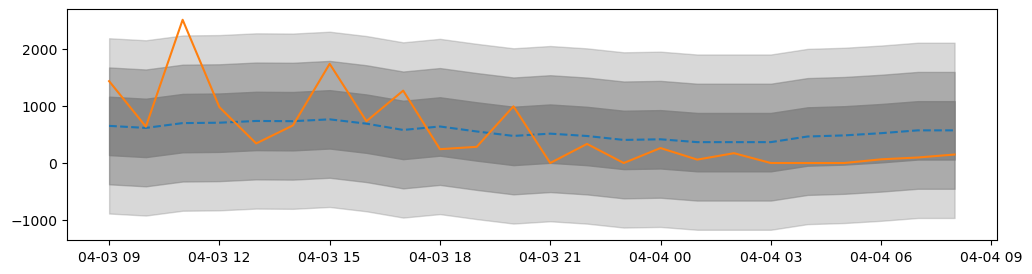

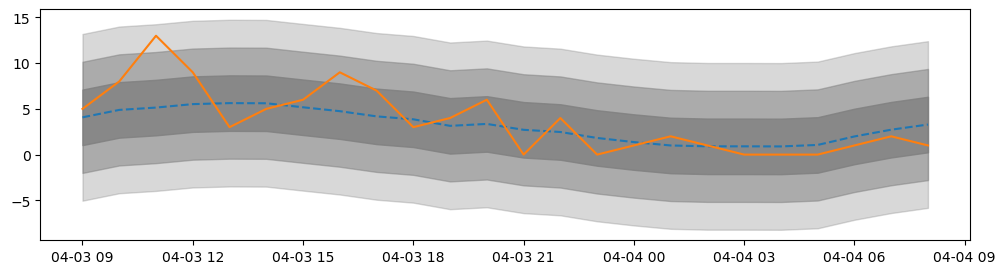

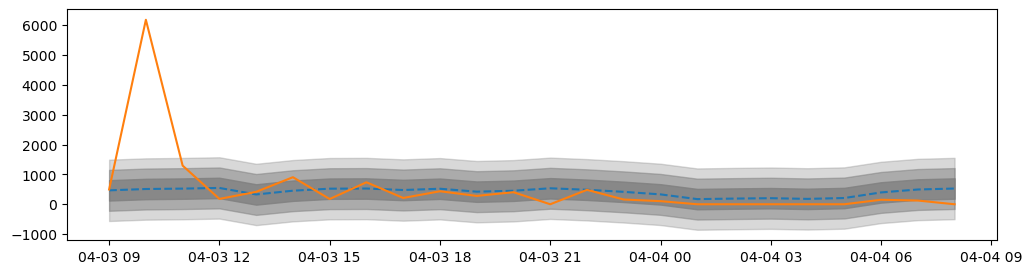

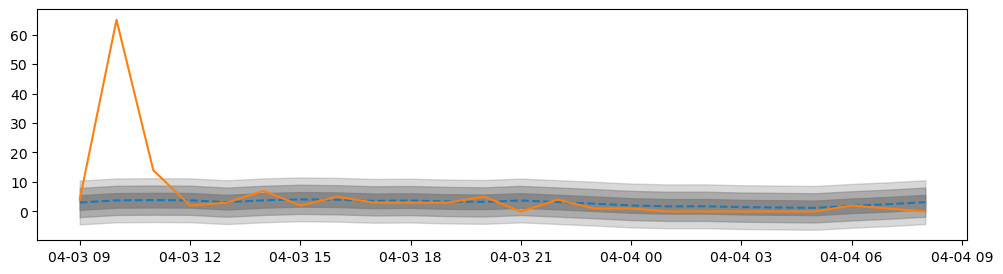

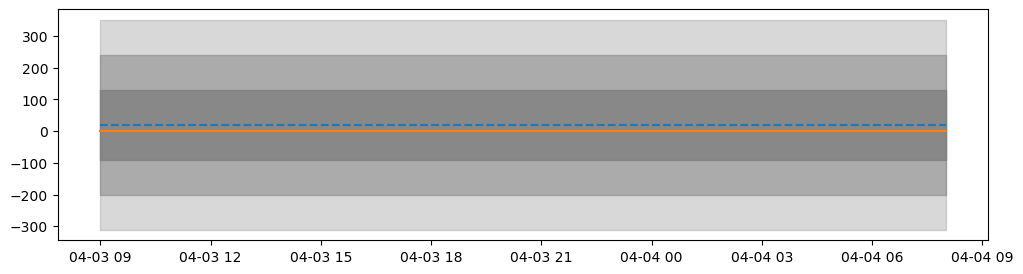

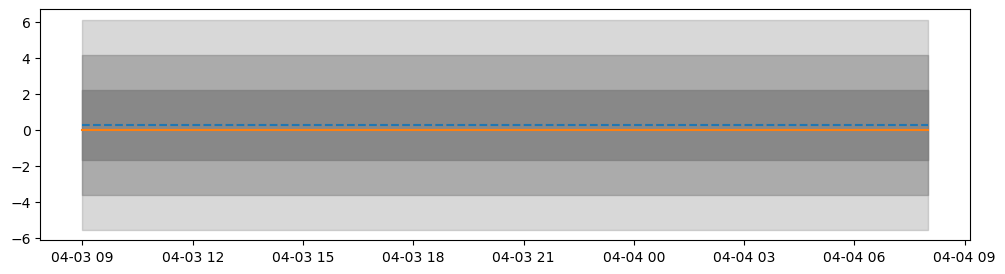

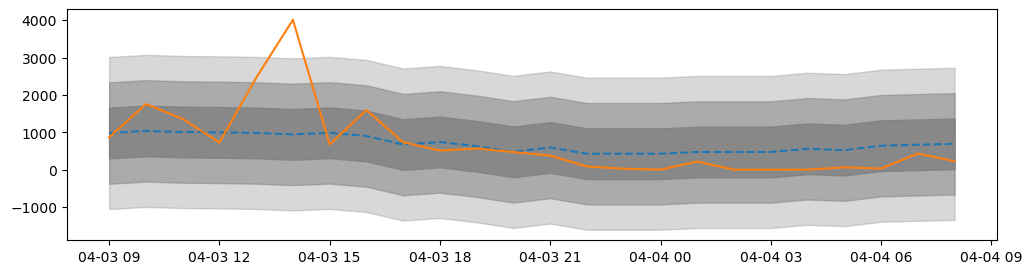

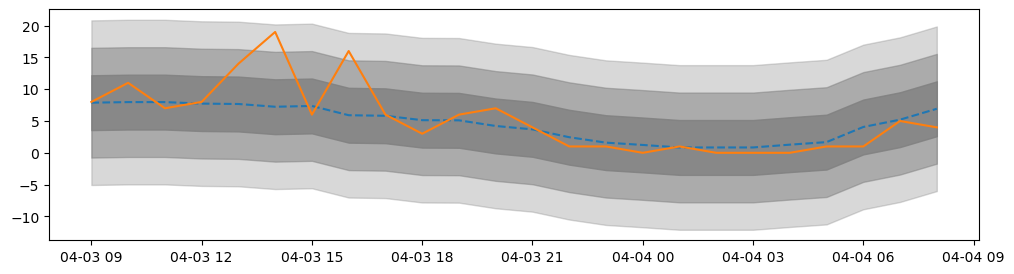

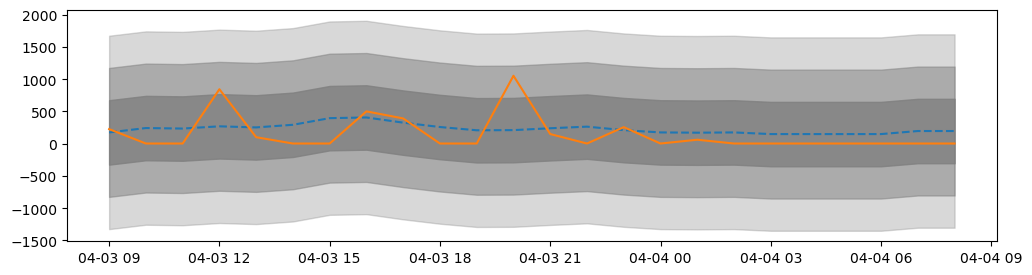

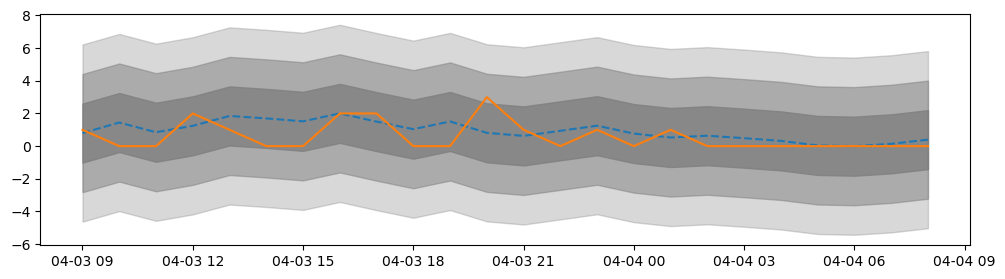

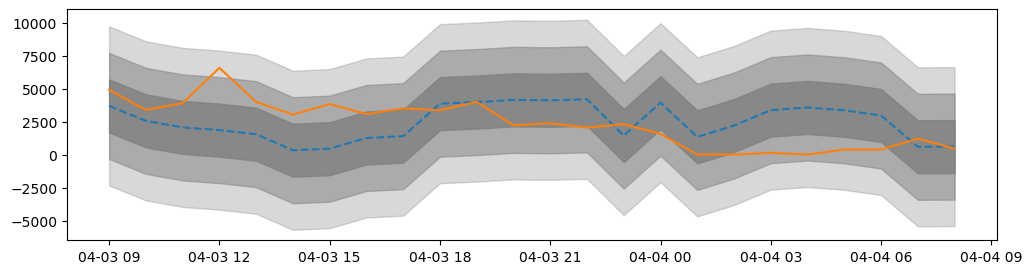

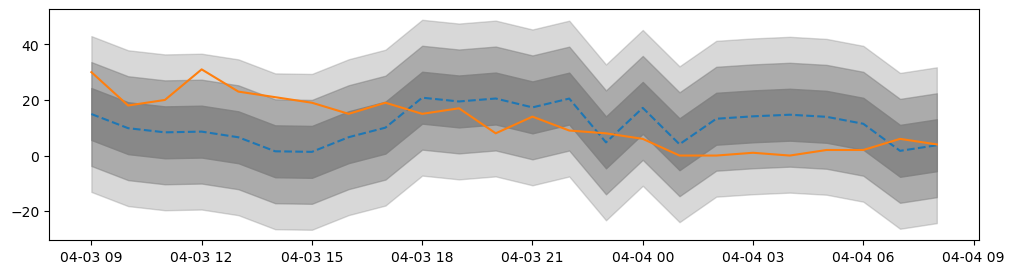

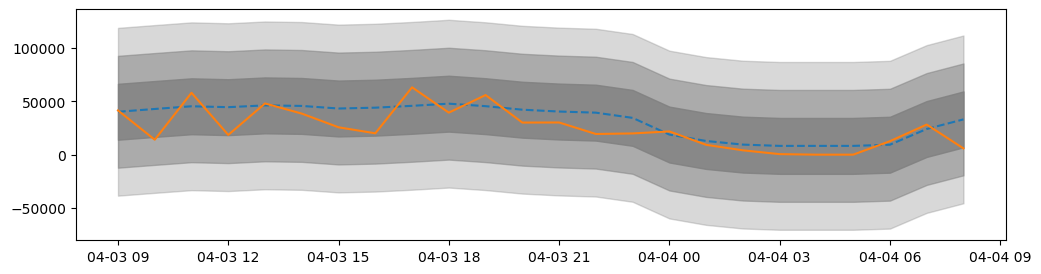

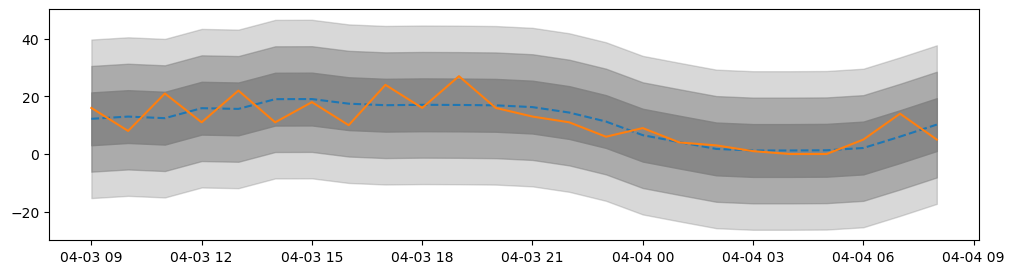

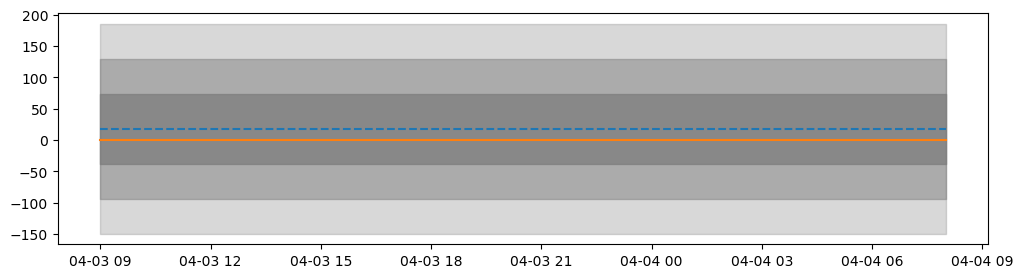

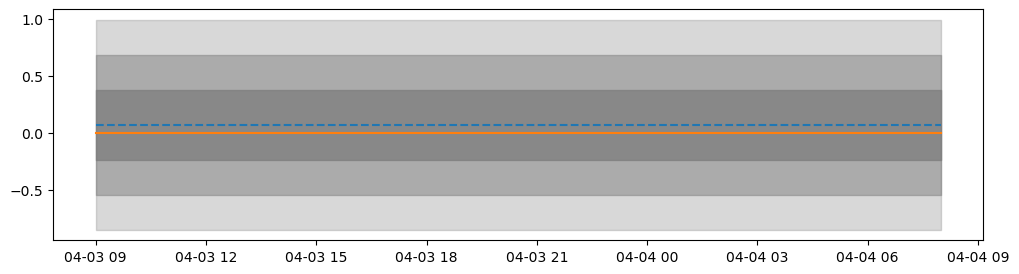

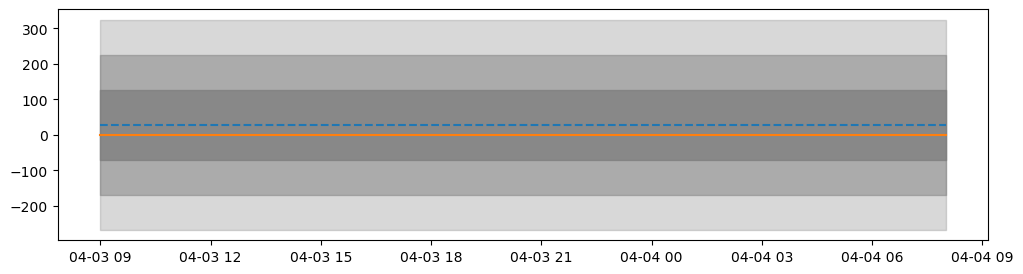

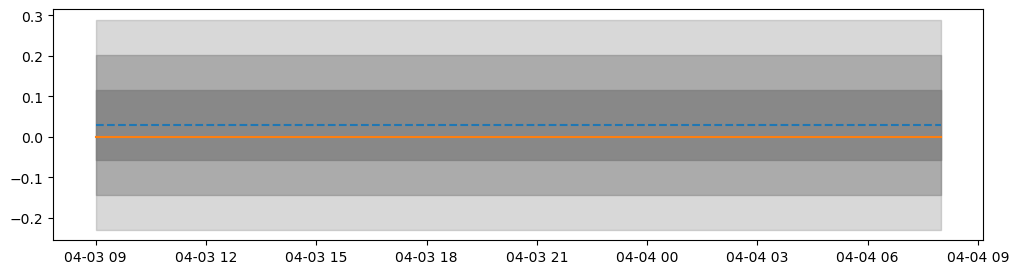

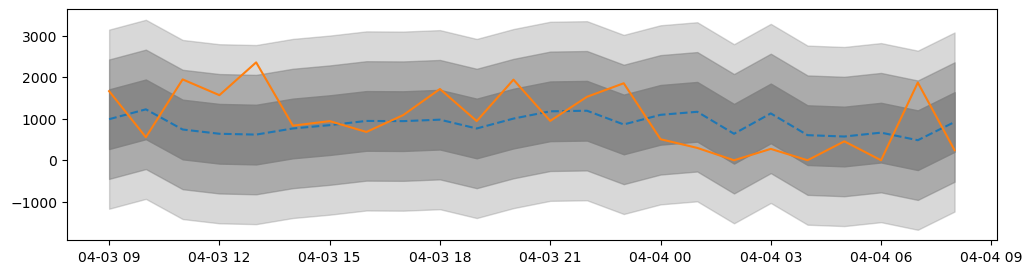

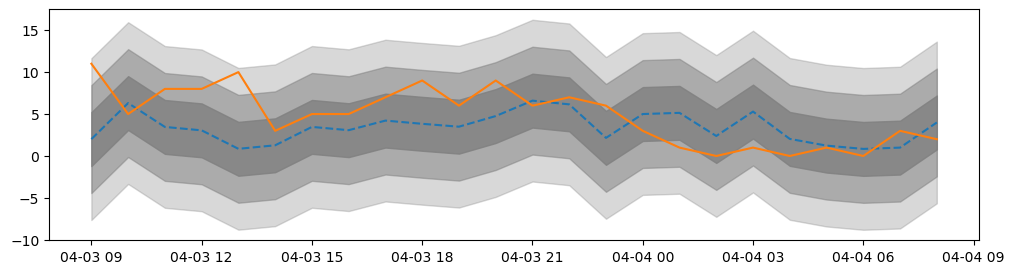

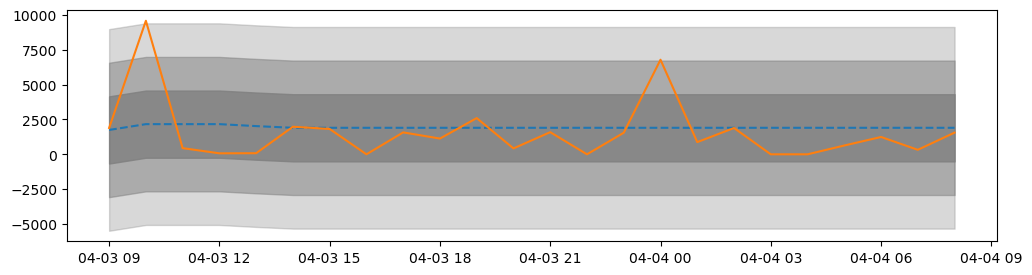

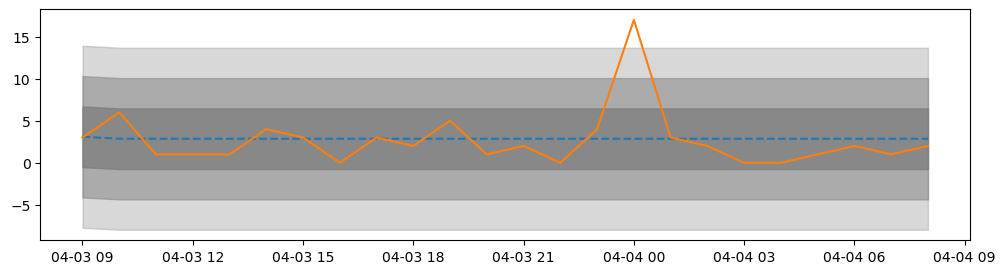

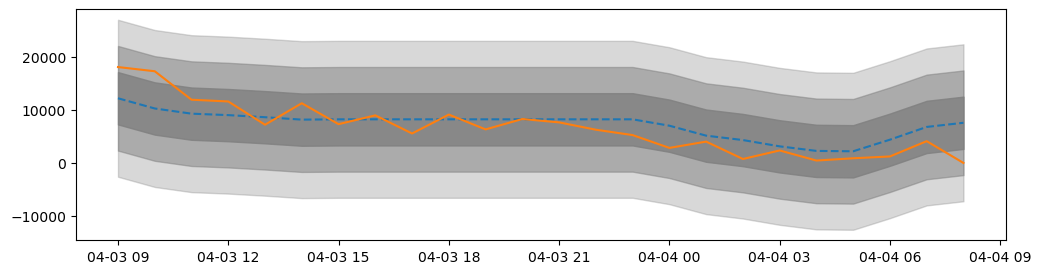

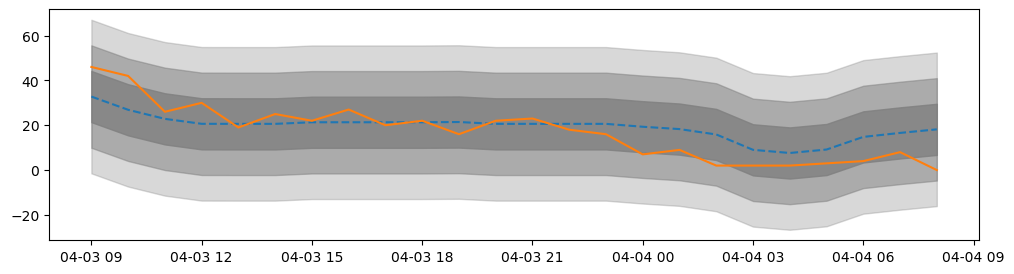

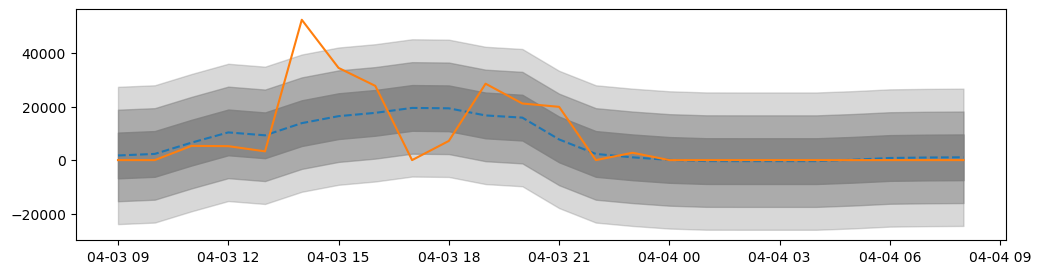

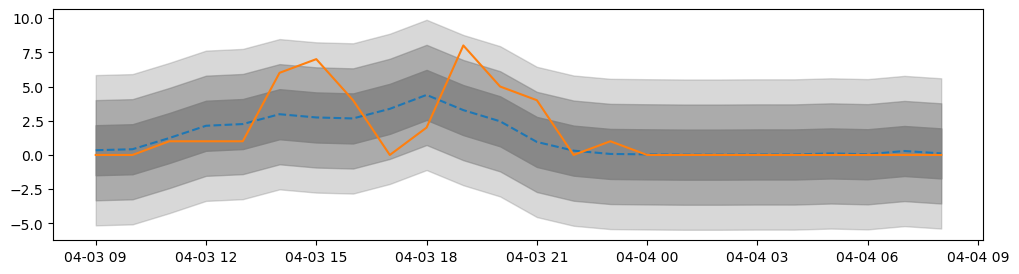

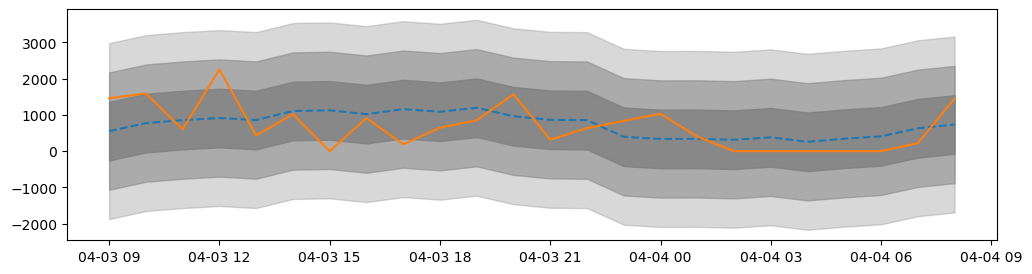

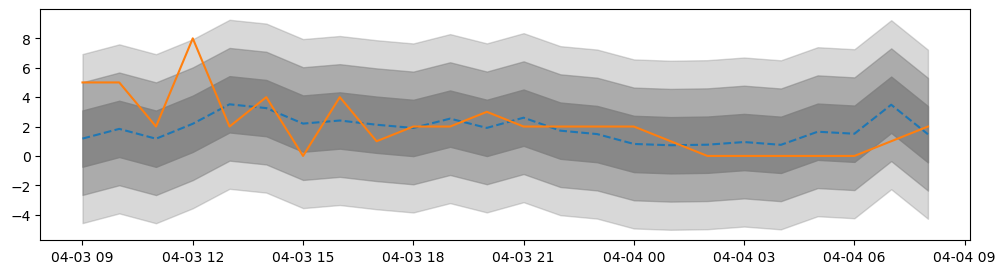

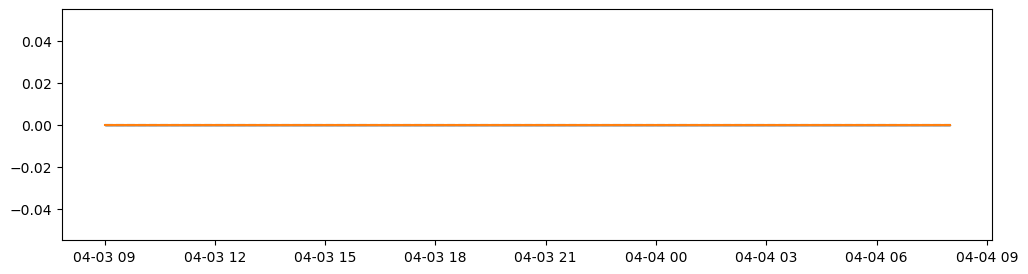

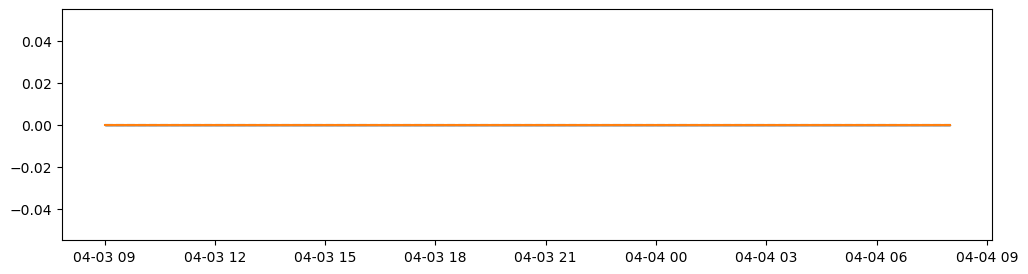

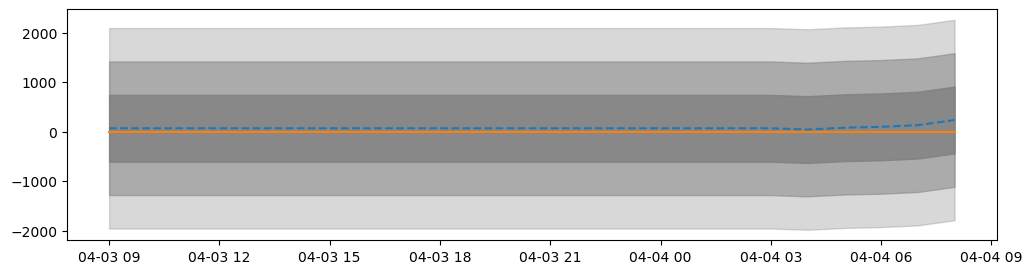

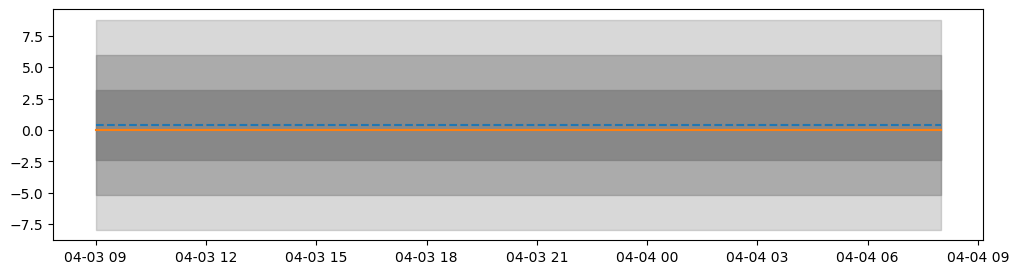

In [ ]:
df_forecast_metrics_norm = {}
scores = {}
# for model in gb_models + lstm_models + tbats_models + ens_models + chronos_models:
for model in models:
    print('\n\n')
    print(model)
    df_forecast_metrics_norm[model] = {}
    
    for account_id, sales_channel_id in id_pairs:
        
        if sales_channel_id == 'ALL':
            cond = (sales['account_id'] == account_id) & \
                   (sales['status'].notna())
        else:
            sales_channel_id = int(sales_channel_id)
            cond = (sales['account_id'] == account_id) & \
                   (sales['sales_channel_id'] == sales_channel_id) & \
                   (sales['status'].notna())
            

        df_client = sales[cond].drop(['account_id', 'sales_channel_id'], axis=1)
        df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
        df_client = df_client.sort_values('created_date').reset_index(drop=True)
        df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)

        df_client_mod = df_client.groupby('created_date').agg(price_total_agg=('price_total', 'sum'), n_orders=('created_date', 'count'))
        df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')

        end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
        start_date = end_date - relativedelta(months=LOOKBACK)
        date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
        df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')\
        
        df_forecast_metrics_norm[model][account_id] = {} if account_id not in df_forecast_metrics_norm[model] else df_forecast_metrics_norm[model][account_id]
        
        for dataset in ['sales', 'orders']:
            if dataset == 'sales':
                col = 'price_total_agg'
            else:
                col = 'n_orders'
            
            df = df_client_mod[col].fillna(0)
            
            y_test = df.loc[(df.index >= START_DATE) & (df.index <= END_DATE)].copy()
        
            cursor.execute(f"select start, {dataset}_high, {dataset}_low, {dataset}_mean from public.forecast where account_id = '{account_id}' and channel = '{sales_channel_id}' and model = '{model}'")
            res = cursor.fetchall()
            
            df_forecast = pd.DataFrame(res, columns=['start', f'{dataset}_high', f'{dataset}_low', f'{dataset}_mean']) #[:len(y_test)].set_index(y_test.index)
            
            df_forecast[f'{dataset}_mean'].index = y_test.index
            df_forecast[f'{dataset}_low'].index = y_test.index
            df_forecast[f'{dataset}_high'].index = y_test.index
            
            forecast_mean = df_forecast[f'{dataset}_mean']
            forecast_low = df_forecast[f'{dataset}_low']
            forecast_high = df_forecast[f'{dataset}_high']
            
            forecast = pd.concat([y_test, forecast_mean, forecast_low, forecast_high], axis=1)
            forecast.columns = ['actual', 'forecast', 'lower', 'upper']
            
            plt.figure(figsize=(12, 3))
            plt.plot(forecast['forecast'], linestyle='--')
            plt.plot(forecast['actual'])
            plt.fill_between(forecast.index, forecast['lower'], forecast['upper'], color='gray', alpha=0.8)
            plt.fill_between(forecast.index, 2*forecast['lower']-forecast['forecast'], 2*forecast['upper']-forecast['forecast'], color='gray', alpha=0.5)
            plt.fill_between(forecast.index, 3*forecast['lower']-2*forecast['forecast'], 3*forecast['upper']-2*forecast['forecast'], color='gray', alpha=0.3)
            plt.savefig(f'check_plots/forecast_{account_id}_{sales_channel_id}_{col}_{model}.png')
            plt.show();
            
            df_forecast = forecast.assign(
                covered_pts=lambda x:
                    4*x['actual'].between(x['lower'], x['upper'], inclusive='both') +
                    2*(x['actual'].between(2*x['lower']-x['forecast'], x['lower'], inclusive='left') + x['actual'].between(x['upper'], 2*x['upper']-x['forecast'], inclusive='right')) +
                    1*(x['actual'].between(3*x['lower']-2*x['forecast'], 2*x['lower']-x['forecast'], inclusive='left') + x['actual'].between(2*x['upper']-x['forecast'], 3*x['upper']-2*x['forecast'], inclusive='right')),
                covered_width=lambda x: x['upper'] - x['lower']
            )
            
            df_forecast_metrics = {}
            df_forecast_metrics['total_covered'] = df_forecast['covered_pts'].sum()
            df_forecast_metrics['avg_covered'] = df_forecast['covered_pts'].mean()
            df_forecast_metrics['avg_covered_width'] = df_forecast['covered_width'].mean()
            
            if dataset == 'orders':
                df_forecast_orders_metrics_norm = df_forecast_metrics['avg_covered'] / (1 + np.log(1+df_forecast_metrics['avg_covered_width']))
            else:
                df_forecast_sales_metrics_norm = df_forecast_metrics['avg_covered'] / (1 + np.log(1+df_forecast_metrics['avg_covered_width']))
        
        weight_chan = weights_chan_df.loc[(weights_chan_df['account_id'] == account_id) & (weights_chan_df['sales_channel_id'] == sales_channel_id), 'weights'].values[0]
        df_forecast_metrics_norm[model][account_id][sales_channel_id] = weight_chan * (1/3*df_forecast_sales_metrics_norm + 2/3*df_forecast_orders_metrics_norm)
        # df_forecast_metrics_norm[model][(account_id, sales_channel_id)] = weight_chan * (1/3*df_forecast_sales_metrics_norm + 2/3*df_forecast_orders_metrics_norm)
        
    scores[model] = np.sum([weights_acc_df[acc_id] * np.sum(list(df_forecast_metrics_norm[model][acc_id].values())) for acc_id in df_forecast_metrics_norm[model].keys()])

In [ ]:
# df_forecast

In [ ]:
scores

In [ ]:
joblib.dump(pd.DataFrame(scores, index=['scores']).T, 'scores1.pkl');

In [ ]:
scores1 = joblib.load('scores1.pkl')
scores2 = joblib.load('scores2.pkl')

scores_overall = pd.concat([scores1, scores2], axis=0).sort_values(by='scores', ascending=False)

scores_overall

In [ ]:
joblib.dump(scores_overall, 'scores_overall.pkl');

In [ ]:
# df_forecast_metrics_norm = pd.DataFrame(df_forecast_metrics_norm).sort_index()

# df_forecast_metrics_norm

In [ ]:
# joblib.dump(df_forecast_metrics_norm, 'df_scores1.pkl');

In [ ]:
# df_scores1 = joblib.load('df_scores1.pkl')
# df_scores2 = joblib.load('df_scores2.pkl')

# df_scores = pd.concat([df_scores1, df_scores2], axis=1).sort_index()

# joblib.dump(df_scores, 'df_scores.pkl');

In [ ]:
# joblib.load('df_scores.pkl').to_csv('scores_per_channel.csv', sep=';', index=True, encoding='latin1')
# joblib.load('scores_overall.pkl').to_csv('scores_overall.csv', sep=';', index=True, encoding='latin1')